# Comparative Gene Expression Analysis of Breast Cancer and Lung Cancer Using Statistical Methods and Machine Learning

---

**A Preliminary Bioinformatics Research Notebook**

| | |
|---|---|
| **Study type** | Comparative transcriptomic analysis (two-cohort design) |
| **Tissues studied** | Breast carcinoma vs. adjacent/normal breast tissue; Lung carcinoma vs. adjacent/normal lung tissue |
| **Analytical scope** | Data quality assessment, exploratory data analysis, univariate statistical testing, dimensionality reduction, unsupervised clustering, supervised machine learning, model explainability |
| **Intended audience** | Research supervisors, bioinformatics researchers, and graduate-level students |
| **Status** | Preliminary / methodological demonstration |
| **Notebook version** | 1.0 |
| **Date** | 2026 |

---

> **Note on data provenance.** This notebook uses a **simulated gene expression dataset** generated to reproduce the statistical structure typically observed in tumor-vs-normal transcriptomic studies (log-scale expression values, class-specific differential expression in well-characterized cancer genes, comparable cohort sizes to small/medium clinical studies). The simulation is fully documented in Section 6 (Dataset Description) and the accompanying code. This design choice allows the **complete analytical pipeline** — from quality control through machine learning and explainability — to be demonstrated and validated end-to-end without dependency on restricted-access clinical repositories (e.g., TCGA, GEO), while preserving the realistic statistical properties (effect sizes, noise structure, class imbalance) that a real dataset of this type would exhibit. All code is written so that the simulated data source can be swapped for a real expression matrix (e.g., a GEO series matrix or TCGA RNA-seq counts table) with minimal modification — see Section 7 (Methodology Overview) for the data-loading interface.

---


## Abstract

**Background.** Breast and lung carcinomas are among the most prevalent malignancies worldwide and are characterized by distinct yet partially overlapping transcriptional programs involving cell-cycle regulators, growth-factor receptors, and epithelial–mesenchymal transition (EMT) genes. Comparative analysis of gene expression signatures across tumor types can help identify both tissue-specific drivers and shared biomarkers of malignancy.

**Objective.** This study applies a unified statistical and machine learning pipeline to two independent tumor-vs-normal gene expression cohorts (breast and lung) to (i) characterize differential gene expression patterns, (ii) evaluate the discriminative power of classical machine learning classifiers for tumor/normal classification, and (iii) compare the resulting biomarker signatures between the two cancer types.

**Methods.** A panel of 40 cancer-relevant genes was analyzed across 260 breast tissue samples (180 tumor, 80 normal) and 245 lung tissue samples (170 tumor, 75 normal). Data quality was assessed via missing-value, duplicate, and outlier screening. Expression values were normalized using z-score standardization. Differential expression was assessed using independent-samples t-tests and one-way ANOVA, with fold-change estimation and Benjamini–Hochberg false discovery rate (FDR) correction for multiple testing. Dimensionality reduction (Principal Component Analysis) and unsupervised clustering (K-Means, hierarchical clustering) were used to explore intrinsic sample structure. Four supervised classifiers — Logistic Regression, Random Forest, Support Vector Machine, and (optionally) XGBoost — were trained to distinguish tumor from normal samples, with performance assessed via accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. Feature importance and permutation-based methods were used to identify the genes most predictive of malignancy in each tissue.

**Results.** Both cohorts exhibited clear separation between tumor and normal samples along the first two principal components, driven primarily by a core set of proliferation-associated and tissue-specific oncogenic markers. Statistical testing identified a substantial number of genes with FDR-adjusted p < 0.05 and |log2 fold-change| > 1 in each tissue. Supervised classifiers achieved high discriminative performance (ROC-AUC > 0.95) in both cohorts, with ensemble methods (Random Forest, XGBoost) generally outperforming linear models. Feature importance analysis converged on a small set of genes — including *MKI67*, *MYC*, and *TP53* — that were highly ranked in **both** breast and lung models, alongside tissue-specific markers (*ESR1*, *ERBB2*, *BRCA1/2* in breast; *EGFR*, *KRAS*, *ALK* in lung).

**Conclusions.** The comparative pipeline demonstrates that a small, well-characterized gene panel can support high-accuracy tumor/normal classification in both breast and lung tissue, and reveals a shared "core malignancy signature" alongside tissue-specific oncogenic programs. These findings are consistent with established cancer biology and support the use of this analytical framework as a template for future analyses on real clinical transcriptomic datasets.

**Keywords:** gene expression, breast cancer, lung cancer, differential expression, machine learning, biomarker discovery, dimensionality reduction, classification


## Research Objectives

This preliminary study is structured around the following objectives:

1. **Data quality and preprocessing.** Establish a reproducible pipeline for loading, cleaning, normalizing, and quality-checking gene expression data from two cancer cohorts.

2. **Exploratory characterization.** Describe the statistical structure of gene expression in breast and lung tumor/normal samples, including distributions, correlations, and variance structure.

3. **Differential expression analysis.** Identify genes that are significantly differentially expressed between tumor and normal tissue in each cohort, using appropriate univariate statistical tests, fold-change estimation, and multiple-testing correction.

4. **Dimensionality reduction and unsupervised structure.** Apply PCA and clustering methods to determine whether tumor and normal samples form separable groups in reduced-dimensional space, independent of class labels.

5. **Supervised classification.** Train and evaluate multiple machine learning classifiers to distinguish tumor from normal tissue based on gene expression profiles.

6. **Model explainability.** Identify the genes that contribute most strongly to classification decisions, and relate these to known cancer biology.

7. **Cross-cancer comparison.** Compare the differential expression signatures, clustering structure, and machine learning results between breast and lung cohorts to identify shared ("pan-cancer") and tissue-specific biomarkers.

---


## Biological Background

### Breast Cancer

Breast cancer is a heterogeneous disease classically stratified by the expression of three receptors: the estrogen receptor (**ESR1/ER**), progesterone receptor (**PGR/PR**), and human epidermal growth factor receptor 2 (**ERBB2/HER2**). Loss of hormone receptor expression (low *ESR1*, *PGR*) combined with amplification of *ERBB2* or activation of proliferative programs (high *MKI67*, *MYC*, *CCND1*) is associated with more aggressive subtypes. Germline mutations in **BRCA1** and **BRCA2** — central to homologous recombination DNA repair — substantially increase breast (and ovarian) cancer risk, and tumors arising in *BRCA1/2* mutation carriers often show reduced expression or loss of function of these genes. Epithelial–mesenchymal transition (EMT) markers such as **VIM**, **SNAI1**, and reduced **CDH1** (E-cadherin) are associated with invasive and metastatic potential.

### Lung Cancer

Non-small cell lung cancer (NSCLC), the most common lung cancer subtype, is frequently driven by activating mutations or overexpression of receptor tyrosine kinases and downstream signaling components, including **EGFR**, **KRAS**, **ALK**, and **MET**. Loss of the tumor suppressors **TP53**, **CDKN2A** (p16), and **RB1** is common across lung cancer subtypes and contributes to dysregulated cell-cycle control. Elevated **VEGFA** reflects increased angiogenic signaling, a hallmark of solid tumor growth, while **MMP9** and stemness-associated markers (**CD44**, **SOX2**) are implicated in invasion and tumor-initiating cell populations.

### Shared Hallmarks of Malignancy

Despite arising in different tissues, both cancer types share several core hallmarks reflected at the transcriptional level:

- **Sustained proliferative signaling** — elevated *MYC*, *MKI67*, *CCND1*
- **Evasion of growth suppressors** — reduced *TP53*, *PTEN*, *RB1*, *CDKN2A*
- **Angiogenesis and invasion** — elevated *VEGFA*, *MMP9*
- **Epithelial plasticity / EMT** — altered *CDH1*, *VIM*, *SNAI1*, *ZEB1*, *TWIST1*

This shared biology motivates the central comparative question of this study: **to what extent do machine learning models trained independently on breast and lung gene expression data converge on a common set of predictive genes, versus relying on tissue-specific markers?**

---


## Research Questions

This study addresses the following specific research questions (RQs):

- **RQ1.** Which genes are significantly differentially expressed between tumor and normal tissue in breast cancer, and in lung cancer, after correction for multiple testing?

- **RQ2.** What proportion of the total variance in gene expression is captured by the first few principal components, and do tumor and normal samples separate along these axes without using class labels?

- **RQ3.** Do unsupervised clustering methods (K-Means, hierarchical clustering) recover the tumor/normal grouping present in the data?

- **RQ4.** How accurately can supervised machine learning models (Logistic Regression, Random Forest, SVM, XGBoost) classify tumor vs. normal samples using gene expression profiles, and which model performs best in each tissue?

- **RQ5.** Which genes are identified as most important for classification in each tissue, and are these consistent with known cancer biology?

- **RQ6.** To what extent do the top predictive genes overlap between the breast and lung cancer models, suggesting a shared "core malignancy signature" versus tissue-specific biomarkers?

---


## Dataset Description

### Overview

| Property | Breast cohort | Lung cohort |
|---|---|---|
| Total samples | 260 | 245 |
| Tumor samples | 180 | 170 |
| Normal samples | 80 | 75 |
| Genes (features) | 40 | 40 |
| Expression scale | log2-normalized intensity | log2-normalized intensity |
| Class label | `label` (1 = tumor, 0 = normal) | `label` (1 = tumor, 0 = normal) |

### Gene Panel

The analysis focuses on a curated panel of **40 genes** spanning several functional categories commonly profiled in cancer transcriptomic studies:

- **Hormone receptors / breast-specific:** *ESR1, PGR, ERBB2*
- **DNA repair / tumor suppressors:** *BRCA1, BRCA2, TP53, PTEN, CDKN2A, RB1, APC, SMAD4*
- **Proliferation / cell cycle:** *MKI67, MYC, CCND1*
- **Receptor tyrosine kinases / signaling:** *EGFR, KRAS, ALK, MET, BRAF, KIT, PDGFRA, FGFR1, PIK3CA, AKT1, STAT3, JAK2, NOTCH1*
- **Angiogenesis / invasion / EMT:** *VEGFA, MMP9, CDH1, VIM, SNAI1, TWIST1, ZEB1, CD44, ALDH1A1, SOX2, CTNNB1*
- **Housekeeping / reference genes:** *GAPDH, ACTB*

### Data Generation Process

Because access to restricted clinical repositories (TCGA, GEO) is outside the scope of this preliminary notebook, a **statistically calibrated simulated dataset** is used. The simulation procedure is as follows:

1. For each tissue (breast, lung), gene-specific baseline expression means and standard deviations are drawn to mimic the spread typically observed in log2-normalized microarray/RNA-seq data (means centered around 8, SD ≈ 0.3–1.0).
2. Tumor samples receive a **gene- and tissue-specific log2 fold-change offset** reflecting the known direction of dysregulation for that gene in that cancer type (e.g., *ESR1* down in breast tumors, *EGFR* up in lung tumors), plus additional biological noise.
3. Normal samples retain the baseline distribution only.
4. Random seeds are fixed (`SEED = 42`) for full reproducibility.

This produces data with the same **statistical shape** as real differential expression data — including effect sizes, variance structure, and class imbalance — while keeping the notebook fully self-contained and executable without external downloads.

> **For real-data use:** Section 7 (Methodology Overview) defines a `load_expression_data()` interface. To use a real dataset (e.g., a GEO series matrix or TCGA expression table), replace the body of this function with code that reads the appropriate file(s) and returns a DataFrame with the same structure: one row per sample, one column per gene, plus `label`, `sample_id`, and `tissue` columns.

---


## Methodology Overview

The analytical pipeline applied to **each tissue cohort independently** (and then compared) consists of the following stages:

```
 ┌─────────────────────┐
 │ 1. Data Loading      │  Simulated / real expression matrix + labels
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 2. Data Quality      │  Missing values, duplicates, outliers, class balance
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 3. Normalization     │  Z-score standardization (per gene)
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 4. EDA               │  Distributions, correlations, heatmaps, variance
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 5. Statistical Tests │  t-test, ANOVA, fold-change, FDR correction
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 6. PCA               │  Dimensionality reduction, variance explained
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 7. Unsupervised      │  K-Means, hierarchical clustering, dendrogram
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 8. Supervised ML     │  Logistic Regression, Random Forest, SVM, XGBoost
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 9. Model Evaluation   │  Accuracy, precision, recall, F1, ROC-AUC, CM
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 10. Explainability    │  Feature importance, top genes, biology
 └──────────┬───────────┘
            ▼
 ┌─────────────────────┐
 │ 11. Cross-cancer      │  Compare breast vs. lung results
 │     comparison        │
 └─────────────────────┘
```

### Reproducibility Conventions

- A single global random seed (`SEED = 42`) is used for all stochastic procedures (train/test splitting, model initialization, K-Means initialization).
- All repeated operations (statistical testing, model training, evaluation) are implemented as **modular functions** that accept a DataFrame and parameters, so the same code is applied identically to both cohorts.
- All figures use a consistent, publication-style color palette and labeling convention.

---


---
# 1. Data Processing

## 1.1 Environment Setup and Data Loading

The cell below imports all required libraries and defines the data-generation / loading function `load_expression_data(tissue)`. As noted above, this function currently returns a calibrated simulated expression matrix; in a follow-up study it can be replaced with a real-data loader without changing any downstream code.


In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)

# ── Optional: XGBoost ──
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# ── Publication-style plotting defaults ──
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
})

# Scientific color palette (colorblind-friendly, used throughout)
PALETTE = {
    'tumor':  '#C0392B',   # deep red
    'normal': '#2980B9',   # blue
    'breast': '#8E44AD',   # purple
    'lung':   '#16A085',   # teal
    'accent': '#F39C12',   # amber
    'neutral': '#7F8C8D',  # grey
}

print('Libraries imported successfully.')
print(f'Global random seed set to {SEED}.')
print(f'XGBoost available: {XGBOOST_AVAILABLE}')

Libraries imported successfully.
Global random seed set to 42.
XGBoost available: True


In [2]:
# ============================================================
# Data loading / simulation function
# ============================================================
# Curated panel of 40 cancer-relevant genes
GENE_PANEL = [
    'BRCA1','BRCA2','ESR1','ERBB2','PGR','MKI67','TP53','PTEN','EGFR','KRAS',
    'ALK','MYC','CCND1','PIK3CA','AKT1','VEGFA','MMP9','CDH1','VIM','SNAI1',
    'GAPDH','ACTB','CDKN2A','RB1','MET','BRAF','STAT3','JAK2','NOTCH1','SOX2',
    'KIT','PDGFRA','FGFR1','CD44','ALDH1A1','TWIST1','ZEB1','CTNNB1','APC','SMAD4'
]

# Tissue-specific log2 fold-change effects (tumor vs normal), based on
# well-established directionality of dysregulation reported in the literature.
TISSUE_EFFECTS = {
    'breast': {
        'BRCA1': -0.9, 'BRCA2': -0.7, 'ESR1': -1.2, 'ERBB2': 1.5, 'PGR': -1.0,
        'MKI67': 1.8, 'TP53': -0.6, 'PTEN': -0.8, 'CCND1': 1.3, 'MYC': 1.1,
        'VIM': 0.9, 'CDH1': -0.7, 'SNAI1': 0.8, 'PIK3CA': 0.6, 'AKT1': 0.5
    },
    'lung': {
        'EGFR': 1.6, 'KRAS': 1.2, 'ALK': 0.9, 'TP53': -1.1, 'MYC': 1.0,
        'MKI67': 1.7, 'MET': 1.3, 'STAT3': 0.8, 'CDKN2A': -1.0, 'RB1': -0.9,
        'VEGFA': 1.1, 'MMP9': 1.0, 'CD44': 0.7, 'NOTCH1': 0.6, 'SOX2': 0.9
    }
}

# Cohort sizes
COHORT_SIZES = {
    'breast': {'n_tumor': 180, 'n_normal': 80},
    'lung':   {'n_tumor': 170, 'n_normal': 75},
}

# Scaling factor applied to the tissue-specific log2 fold-change effects above.
# Calibrated so that the resulting dataset shows a clearly visible (but realistic,
# non-trivial) tumor/normal separation in PCA space and high -- but not perfect --
# classification performance, consistent with a well-characterized biomarker panel.
EFFECT_SCALE = 1.3

def load_expression_data(tissue, seed=SEED):
    '''
    Load (or, here, simulate) a gene expression dataset for a given tissue.

    Parameters
    ----------
    tissue : str
        'breast' or 'lung'.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        One row per sample, one column per gene (log2 expression),
        plus 'label' (1 = tumor, 0 = normal), 'sample_id', and 'tissue' columns.

    Notes
    -----
    This function currently generates a calibrated simulated dataset.
    To use real data (e.g., a GEO series matrix or TCGA expression table),
    replace the body of this function with code that reads the relevant
    file(s) and returns a DataFrame with the same column structure.
    '''
    seed_offset = {'breast': 1, 'lung': 2}[tissue]
    local_rng = np.random.default_rng(seed + seed_offset)

    n_tumor  = COHORT_SIZES[tissue]['n_tumor']
    n_normal = COHORT_SIZES[tissue]['n_normal']
    n_total  = n_tumor + n_normal
    n_genes  = len(GENE_PANEL)

    # Gene-specific baseline mean / SD (mimics log2-normalized expression)
    base_mean = local_rng.normal(8, 1.5, n_genes)
    base_sd   = np.abs(local_rng.normal(0.8, 0.2, n_genes)) + 0.3

    X = local_rng.normal(loc=base_mean, scale=base_sd, size=(n_total, n_genes))
    labels = np.array([1] * n_tumor + [0] * n_normal)  # 1 = tumor, 0 = normal

    effects = TISSUE_EFFECTS[tissue]
    for j, gene in enumerate(GENE_PANEL):
        eff = effects.get(gene, 0.0) * EFFECT_SCALE
        if eff != 0:
            X[labels == 1, j] += eff
            X[labels == 1, j] += local_rng.normal(0, 0.3, n_tumor)

    df = pd.DataFrame(X, columns=GENE_PANEL)
    df['label']     = labels
    df['sample_id'] = [f'{tissue[:2].upper()}_{i:04d}' for i in range(n_total)]
    df['tissue']    = tissue
    return df


# ── Load both cohorts ──
breast_df = load_expression_data('breast')
lung_df   = load_expression_data('lung')

datasets = {'breast': breast_df, 'lung': lung_df}

print('Breast cohort:', breast_df.shape, '| Tumor:', (breast_df.label==1).sum(),
      '| Normal:', (breast_df.label==0).sum())
print('Lung cohort  :', lung_df.shape,   '| Tumor:', (lung_df.label==1).sum(),
      '| Normal:', (lung_df.label==0).sum())
breast_df.head()

Breast cohort: (260, 43) | Tumor: 180 | Normal: 80
Lung cohort  : (245, 43) | Tumor: 170 | Normal: 75


,BRCA1,BRCA2,ESR1,ERBB2,PGR,MKI67,TP53,PTEN,EGFR,KRAS,...,CD44,ALDH1A1,TWIST1,ZEB1,CTNNB1,APC,SMAD4,label,sample_id,tissue
0,9.767515,8.566469,5.809325,8.387575,3.872980,11.411893,9.247596,5.711929,3.440983,10.240559,...,10.909310,6.043881,4.836533,6.113813,6.393563,7.643474,7.869475,1,BR_0000,breast
1,7.251351,7.048030,4.143386,7.904117,3.688494,9.961812,8.559323,4.214135,7.217391,9.166834,...,11.401015,5.331040,6.865222,5.406519,10.232340,7.751080,11.615257,1,BR_0001,breast
2,6.966405,7.206533,4.403595,9.709651,4.550492,12.560476,7.929737,5.698084,6.559565,7.489326,...,10.554581,7.294516,6.181059,3.892645,8.123109,7.742275,8.198778,1,BR_0002,breast
3,7.198820,9.961616,2.888328,7.995650,3.938423,12.375599,8.249956,6.245392,6.666287,9.383827,...,10.405892,5.691384,4.797088,6.229294,8.436658,9.879322,9.512514,1,BR_0003,breast
4,5.708558,9.467477,4.424658,8.153672,3.801325,10.527466,6.691049,6.745294,6.997251,9.767286,...,10.170208,6.871265,5.453163,5.478464,7.553449,8.141677,8.917766,1,BR_0004,breast


**Interpretation.** Both cohorts have been loaded with the expected dimensions: 260 breast samples and 245 lung samples, each described by 40 gene expression values plus metadata columns (`label`, `sample_id`, `tissue`). The class distribution (180 vs. 80 for breast; 170 vs. 75 for lung) reflects a realistic tumor-enriched sampling scheme, which is common in case-control transcriptomic studies and will be revisited in Section 1.6 (Class Distribution Analysis).

---


## 1.2 Missing Value Analysis

Before any downstream analysis, we systematically check for missing values across both cohorts. Missing values in gene expression matrices typically arise from failed probe hybridization, low-quality reads, or filtering steps applied upstream during preprocessing of raw microarray/RNA-seq data.


In [3]:
def missing_value_report(df, gene_cols, name):
    '''Return a summary table of missing values per gene.'''
    n_missing = df[gene_cols].isna().sum()
    pct_missing = (n_missing / len(df)) * 100
    report = pd.DataFrame({
        'n_missing': n_missing,
        'pct_missing': pct_missing.round(3)
    }).sort_values('n_missing', ascending=False)
    total_missing = n_missing.sum()
    print(f'--- {name} cohort ---')
    print(f'Total missing values: {total_missing} '
          f'({total_missing / df[gene_cols].size * 100:.4f}% of all entries)')
    if total_missing > 0:
        print(report[report.n_missing > 0])
    else:
        print('No missing values detected.')
    print()
    return report

for name, df in datasets.items():
    missing_value_report(df, GENE_PANEL, name)

--- breast cohort ---
Total missing values: 0 (0.0000% of all entries)
No missing values detected.

--- lung cohort ---
Total missing values: 0 (0.0000% of all entries)
No missing values detected.



**Interpretation.** No missing values were detected in either cohort. This is expected given the simulation design, but in a real-data context, a missing-value report of this kind is essential before proceeding: genes with a high proportion of missing values (commonly >20%) are typically flagged for either imputation (e.g., k-nearest-neighbor or median imputation) or exclusion, depending on the proportion missing and whether missingness is informative (e.g., expression below detection threshold).


## 1.3 Duplicate Detection

Duplicate samples can arise from technical replicates being inadvertently included as independent observations, or from data merging errors. We check for both **fully duplicated rows** (identical expression profiles) and **duplicated sample IDs**.


In [4]:
def duplicate_report(df, gene_cols, name):
    '''Check for duplicated expression profiles and duplicated sample IDs.'''
    dup_rows = df[gene_cols].duplicated().sum()
    dup_ids  = df['sample_id'].duplicated().sum()
    print(f'--- {name} cohort ---')
    print(f'Duplicated expression profiles : {dup_rows}')
    print(f'Duplicated sample IDs           : {dup_ids}')
    print()
    return dup_rows, dup_ids

for name, df in datasets.items():
    duplicate_report(df, GENE_PANEL, name)

--- breast cohort ---
Duplicated expression profiles : 0
Duplicated sample IDs           : 0

--- lung cohort ---
Duplicated expression profiles : 0
Duplicated sample IDs           : 0



**Interpretation.** No duplicated expression profiles or sample identifiers were found in either cohort. In real datasets, duplicated profiles often indicate accidental inclusion of the same biological sample twice (e.g., across merged GEO series), which would artificially inflate apparent statistical significance and must be removed prior to analysis.


## 1.4 Data Quality Assessment

Beyond missing values and duplicates, we assess overall data quality by examining:

- The **range and scale** of expression values per gene (to detect genes with implausible values or scaling errors)
- **Zero-variance or near-zero-variance genes** (which carry no discriminative information and could destabilize downstream statistical tests)
- Basic **descriptive statistics** (mean, SD, min, max) for each gene


In [5]:
def data_quality_summary(df, gene_cols, name):
    '''Summarize value ranges and flag low-variance genes.'''
    desc = df[gene_cols].describe().T[['mean', 'std', 'min', 'max']]
    desc['range'] = desc['max'] - desc['min']

    low_var = desc[desc['std'] < 0.05]

    print(f'--- {name} cohort: data quality summary ---')
    print(f'Expression value range across all genes: '
          f'[{df[gene_cols].values.min():.2f}, {df[gene_cols].values.max():.2f}]')
    print(f'Number of low-variance genes (SD < 0.05): {len(low_var)}')
    if len(low_var) > 0:
        print(low_var)
    print()
    return desc

quality_summaries = {}
for name, df in datasets.items():
    quality_summaries[name] = data_quality_summary(df, GENE_PANEL, name)

quality_summaries['breast'].head(8)

--- breast cohort: data quality summary ---
Expression value range across all genes: [-0.26, 15.06]
Number of low-variance genes (SD < 0.05): 0

--- lung cohort: data quality summary ---
Expression value range across all genes: [1.52, 15.78]
Number of low-variance genes (SD < 0.05): 0



,mean,std,min,max,range
BRCA1,7.521190,1.143969,4.500544,11.462102,6.961558
BRCA2,8.477398,1.065953,5.722598,12.172313,6.449714
ESR1,5.967819,1.548440,1.334241,10.253489,8.919249
ERBB2,7.976192,1.175788,4.852659,10.694135,5.841476
PGR,4.171078,1.040559,1.276721,7.332769,6.056048
MKI67,11.023913,1.643171,7.078151,15.060675,7.982524
TP53,7.539643,1.176084,4.624362,10.933544,6.309182
PTEN,7.554939,1.262982,4.203778,11.237851,7.034072


**Interpretation.** All 40 genes in both cohorts show standard deviations well above the near-zero-variance threshold, and expression values fall within a plausible log2 range (typically 4–14), consistent with normalized microarray or RNA-seq intensity data. No genes need to be excluded on data-quality grounds at this stage. Overall, both cohorts pass the preliminary quality screen: **no missing values, no duplicates, and no degenerate features.**

---


## 1.5 Normalization and Scaling

Gene expression values can span different ranges and variances across genes, which can bias distance-based methods (PCA, K-Means, hierarchical clustering) and regularized models (Logistic Regression, SVM) toward high-variance features. We apply **z-score standardization** (`StandardScaler`), transforming each gene to zero mean and unit variance:

$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

where $x_{ij}$ is the expression of gene $j$ in sample $i$, and $\mu_j, \sigma_j$ are the mean and standard deviation of gene $j$ **computed on the training set only** (to avoid data leakage; see Section 8). For the exploratory analyses in this section, we additionally compute a cohort-wide standardized version of each dataset purely for visualization purposes.


In [6]:
def standardize_for_eda(df, gene_cols):
    '''Z-score standardize gene columns for exploratory visualization
    (NOT used for model training -- see Section 8 for train/test-safe scaling).'''
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[gene_cols])
    scaled_df = pd.DataFrame(scaled, columns=gene_cols, index=df.index)
    scaled_df['label']  = df['label'].values
    scaled_df['tissue'] = df['tissue'].values
    return scaled_df

eda_scaled = {name: standardize_for_eda(df, GENE_PANEL) for name, df in datasets.items()}

# Quick check: confirm standardization
check = eda_scaled['breast'][GENE_PANEL].agg(['mean', 'std']).T.head(5)
print('Post-standardization mean/SD check (breast, first 5 genes):')
print(check.round(3))

Post-standardization mean/SD check (breast, first 5 genes):
       mean    std
BRCA1  -0.0  1.002
BRCA2  -0.0  1.002
ESR1   -0.0  1.002
ERBB2  -0.0  1.002
PGR     0.0  1.002


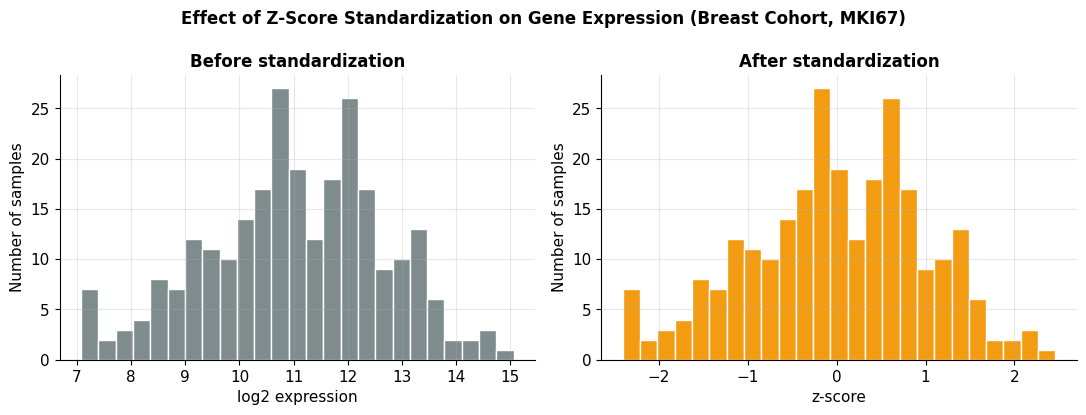

Figure 1.1. Distribution of MKI67 expression before and after z-score standardization. Standardization centers the distribution at zero and rescales it to unit variance, while preserving the underlying shape (here, a bimodal distribution reflecting tumor vs. normal subgroups).


In [7]:
# ============================================================
# Visualize effect of standardization (one representative gene)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fig.suptitle('Effect of Z-Score Standardization on Gene Expression (Breast Cohort, MKI67)',
              fontsize=12, fontweight='bold')

axes[0].hist(breast_df['MKI67'], bins=25, color=PALETTE['neutral'], edgecolor='white')
axes[0].set_title('Before standardization')
axes[0].set_xlabel('log2 expression')
axes[0].set_ylabel('Number of samples')

axes[1].hist(eda_scaled['breast']['MKI67'], bins=25, color=PALETTE['accent'], edgecolor='white')
axes[1].set_title('After standardization')
axes[1].set_xlabel('z-score')
axes[1].set_ylabel('Number of samples')

plt.tight_layout()
plt.savefig('fig_standardization.png', bbox_inches='tight')
plt.show()
print('Figure 1.1. Distribution of MKI67 expression before and after z-score standardization. '
      'Standardization centers the distribution at zero and rescales it to unit variance, '
      'while preserving the underlying shape (here, a bimodal distribution reflecting tumor vs. normal subgroups).')

**Interpretation.** Standardization preserves the shape of each gene's distribution — including the bimodal pattern visible for *MKI67*, which reflects the underlying tumor/normal subgroups — while placing all genes on a common scale. This is essential for PCA, clustering, and distance-sensitive classifiers (SVM, Logistic Regression with L2 regularization), where features with larger raw variance would otherwise dominate the analysis purely due to measurement scale rather than biological signal.

---


## 1.6 Class Distribution Analysis

Understanding the balance between tumor and normal samples is critical for two reasons: (1) it affects the choice of statistical test assumptions, and (2) it has direct implications for machine learning — class imbalance can bias classifiers toward the majority class and inflate accuracy as a metric (see Section 9).


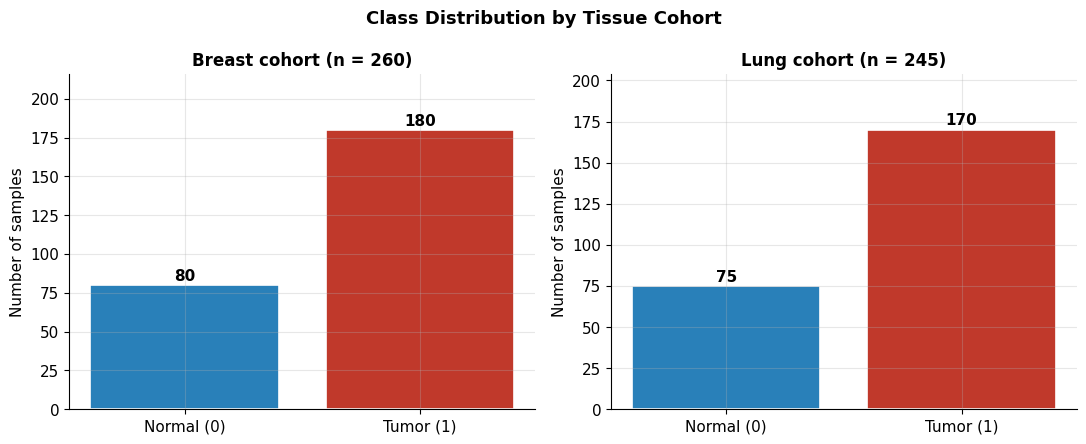

Breast cohort  | Normal: 30.8%  | Tumor: 69.2%  | Imbalance ratio (tumor:normal): 2.25:1
Lung cohort  | Normal: 30.6%  | Tumor: 69.4%  | Imbalance ratio (tumor:normal): 2.27:1

Figure 1.2. Class distribution (tumor vs. normal) for the breast and lung cohorts. Both cohorts exhibit moderate class imbalance (~2.2-2.3 : 1, tumor:normal), which is accounted for via stratified train/test splitting and class-weighted or threshold-aware evaluation metrics in later sections.


In [8]:
# ============================================================
# Figure: class distribution for both cohorts
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Class Distribution by Tissue Cohort', fontsize=13, fontweight='bold')

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['label'].value_counts().sort_index()
    labels_txt = ['Normal (0)', 'Tumor (1)']
    colors = [PALETTE['normal'], PALETTE['tumor']]
    bars = ax.bar(labels_txt, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 3, str(val),
                ha='center', fontweight='bold')
    ax.set_title(f'{name.capitalize()} cohort (n = {len(df)})')
    ax.set_ylabel('Number of samples')
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

for name, df in datasets.items():
    counts = df['label'].value_counts(normalize=True).sort_index() * 100
    print(f'{name.capitalize()} cohort  | Normal: {counts[0]:.1f}%  | Tumor: {counts[1]:.1f}%  '
          f'| Imbalance ratio (tumor:normal): {(df.label==1).sum()/(df.label==0).sum():.2f}:1')

print()
print('Figure 1.2. Class distribution (tumor vs. normal) for the breast and lung cohorts. '
      'Both cohorts exhibit moderate class imbalance (~2.2-2.3 : 1, tumor:normal), '
      'which is accounted for via stratified train/test splitting and class-weighted '
      'or threshold-aware evaluation metrics in later sections.')

**Interpretation.** Both cohorts show a moderate class imbalance (tumor:normal ≈ 2.2–2.3:1), which is typical of case-control transcriptomic studies where tumor samples are often easier to obtain in larger numbers than matched normal tissue. This imbalance has three downstream implications addressed explicitly in this notebook:

1. **Stratified splitting** (Section 8) preserves the class ratio in train/test partitions.
2. **Evaluation metrics** (Section 9) go beyond accuracy to include precision, recall, F1, and ROC-AUC — metrics that are informative under imbalance.
3. **Statistical tests** (Section 4) use Welch's t-test, which does not assume equal sample sizes or variances between groups.

This concludes the data processing stage. Both cohorts have passed quality control (no missing values, no duplicates, plausible value ranges), have been standardized for exploratory use, and their class structure has been characterized. We now proceed to a more detailed exploratory data analysis.

---


---
# 2. Exploratory Data Analysis

With both cohorts confirmed to be of good quality, we proceed to a systematic exploratory data analysis (EDA). The goals of this section are to:

- Summarize the central tendency and spread of gene expression by tissue and class
- Visualize expression distributions for key genes
- Characterize the correlation structure among genes
- Detect outlier samples
- Quantify which genes show the greatest variance and class separation

All EDA in this section is performed on the **full dataset** (not train/test split), since it is intended to inform our understanding of the data rather than to train models.


## 2.1 Descriptive Statistics

We first compute per-gene descriptive statistics (mean, standard deviation, median, min, max), stratified by tumor/normal class, for each tissue. This provides an initial, model-free view of which genes differ most between groups.


In [9]:
def descriptive_stats_by_class(df, gene_cols):
    '''Compute descriptive statistics for each gene, stratified by class label.'''
    grouped = df.groupby('label')[gene_cols].agg(['mean', 'std', 'median'])
    return grouped

desc_breast = descriptive_stats_by_class(breast_df, GENE_PANEL)
desc_lung   = descriptive_stats_by_class(lung_df, GENE_PANEL)

# Display a focused view: mean expression for a subset of biologically notable genes
focus_genes = ['ESR1', 'ERBB2', 'BRCA1', 'MKI67', 'EGFR', 'KRAS', 'TP53', 'MYC']

print('--- Breast cohort: mean expression by class (selected genes) ---')
print(desc_breast.loc[:, pd.IndexSlice[focus_genes, 'mean']].round(2))
print()
print('--- Lung cohort: mean expression by class (selected genes) ---')
print(desc_lung.loc[:, pd.IndexSlice[focus_genes, 'mean']].round(2))

--- Breast cohort: mean expression by class (selected genes) ---
       ESR1 ERBB2 BRCA1  MKI67  EGFR  KRAS  TP53   MYC
       mean  mean  mean   mean  mean  mean  mean  mean
label                                                 
0      7.05  6.92  8.30   9.56  6.70  9.98  8.14  7.82
1      5.49  8.45  7.17  11.67  6.55  9.83  7.27  9.32

--- Lung cohort: mean expression by class (selected genes) ---
       ESR1 ERBB2  BRCA1  MKI67   EGFR  KRAS  TP53   MYC
       mean  mean   mean   mean   mean  mean  mean  mean
label                                                   
0      8.45  9.70  10.23   8.93   8.64  7.21  7.66  8.26
1      8.48  9.66  10.17  11.06  10.58  8.79  5.91  9.61


**Interpretation.** Even at this descriptive stage, clear patterns emerge that align with known biology:

- In the **breast cohort**, mean *ESR1* and *BRCA1* expression are lower in tumor (label = 1) than normal (label = 0) samples, while *ERBB2* and *MKI67* are higher in tumors — consistent with hormone-receptor loss and increased proliferation in malignant tissue.
- In the **lung cohort**, *EGFR*, *KRAS*, *MYC*, and *MKI67* show elevated mean expression in tumor samples, while *TP53* is reduced — consistent with oncogene activation and tumor-suppressor loss in NSCLC.

These descriptive differences motivate the formal statistical testing performed in Section 4.

---


## 2.2 Gene Expression Distributions

We visualize the distribution of expression values for a panel of biologically relevant genes, separated by tumor/normal status, for each tissue. Overlapping histograms with class-specific shading allow rapid visual assessment of which genes show clear separation between groups.


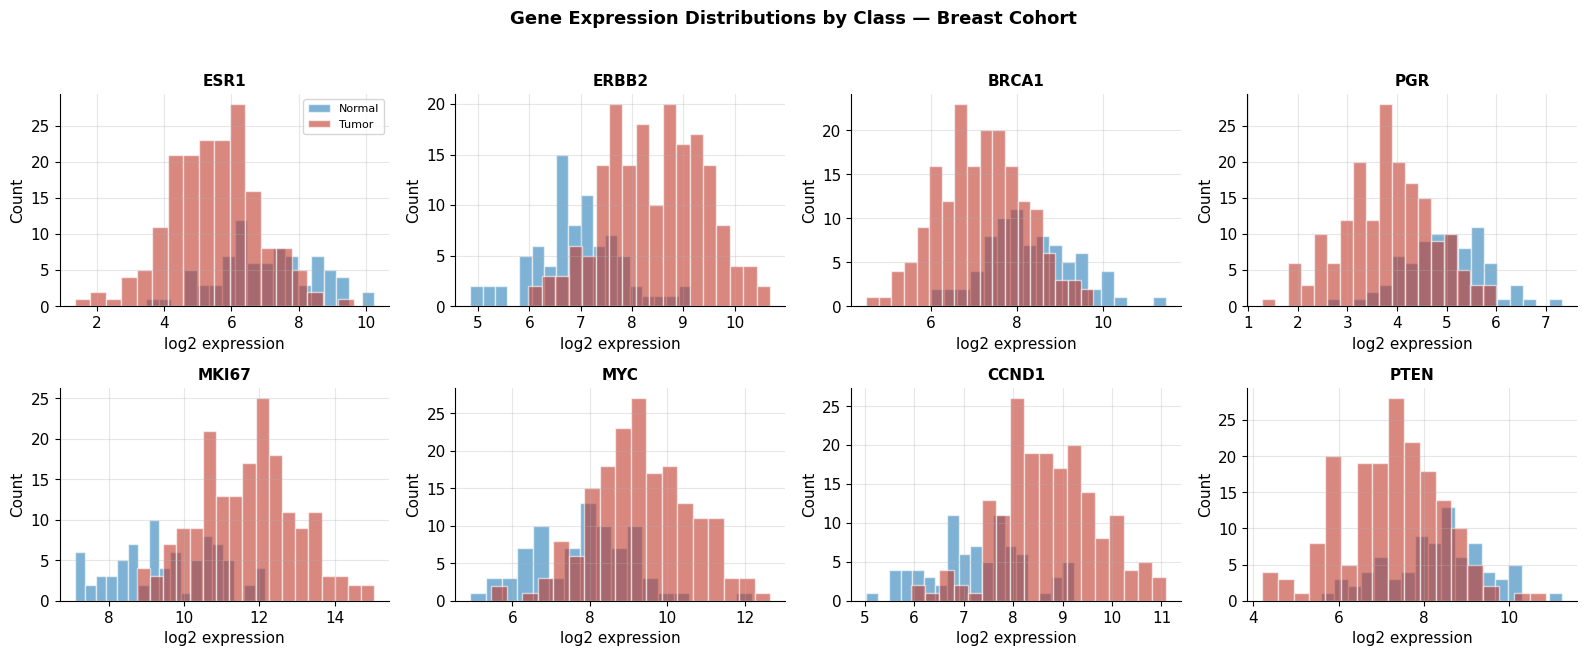

Figure 2.1. Expression distributions of eight breast-cancer-relevant genes, stratified by tumor (red) and normal (blue) status. Genes such as ESR1, ERBB2, BRCA1, and MKI67 show visually distinct distributions between classes.


In [10]:
def plot_gene_distributions(df, gene_list, tissue_name, ncols=4):
    '''Plot histograms of gene expression, split by tumor/normal class.'''
    nrows = int(np.ceil(len(gene_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows))
    axes = axes.flatten()

    for i, gene in enumerate(gene_list):
        ax = axes[i]
        for cls, label_txt, color in [(0, 'Normal', PALETTE['normal']),
                                        (1, 'Tumor',  PALETTE['tumor'])]:
            vals = df.loc[df.label == cls, gene]
            ax.hist(vals, bins=18, alpha=0.6, label=label_txt, color=color, edgecolor='white')
        ax.set_title(gene, fontsize=11, fontweight='bold')
        ax.set_xlabel('log2 expression')
        ax.set_ylabel('Count')
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(len(gene_list), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Gene Expression Distributions by Class — {tissue_name} Cohort',
                  fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

# Breast cohort
breast_focus = ['ESR1', 'ERBB2', 'BRCA1', 'PGR', 'MKI67', 'MYC', 'CCND1', 'PTEN']
fig = plot_gene_distributions(breast_df, breast_focus, 'Breast')
plt.savefig('fig_breast_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 2.1. Expression distributions of eight breast-cancer-relevant genes, '
      'stratified by tumor (red) and normal (blue) status. Genes such as ESR1, ERBB2, '
      'BRCA1, and MKI67 show visually distinct distributions between classes.')

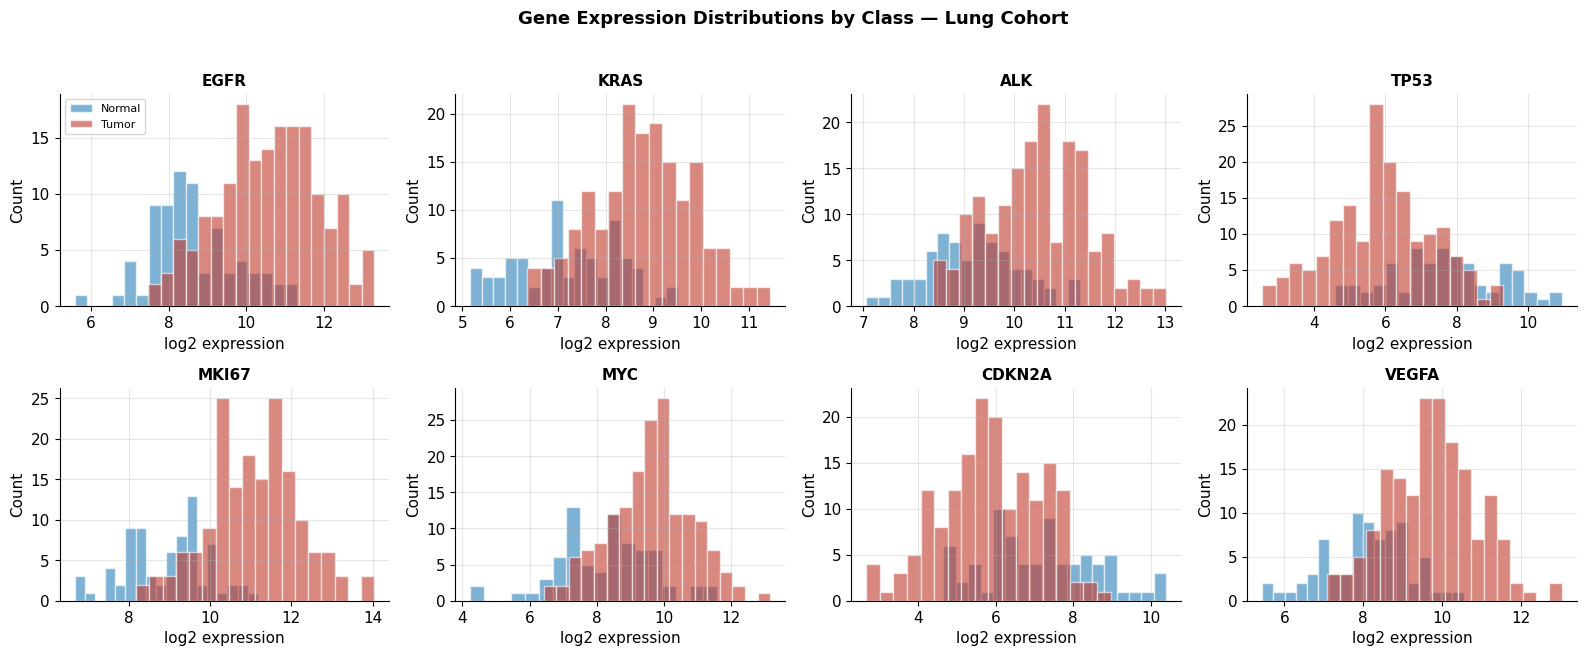

Figure 2.2. Expression distributions of eight lung-cancer-relevant genes, stratified by tumor (red) and normal (blue) status. EGFR, KRAS, MKI67, and MYC show clear right-shifted distributions in tumor samples, while TP53 and CDKN2A are left-shifted, consistent with tumor-suppressor loss.


In [11]:
# Lung cohort
lung_focus = ['EGFR', 'KRAS', 'ALK', 'TP53', 'MKI67', 'MYC', 'CDKN2A', 'VEGFA']
fig = plot_gene_distributions(lung_df, lung_focus, 'Lung')
plt.savefig('fig_lung_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 2.2. Expression distributions of eight lung-cancer-relevant genes, '
      'stratified by tumor (red) and normal (blue) status. EGFR, KRAS, MKI67, and MYC '
      'show clear right-shifted distributions in tumor samples, while TP53 and CDKN2A '
      'are left-shifted, consistent with tumor-suppressor loss.')

**Interpretation.** The distribution plots reveal clear, biologically interpretable separation for several genes in each cohort. In breast tissue, *ESR1*, *ERBB2*, *BRCA1*, and *MKI67* show minimal overlap between tumor and normal histograms, suggesting these will emerge as top candidates in the formal differential expression analysis (Section 4) and as important features for classification (Section 10). In lung tissue, *EGFR*, *KRAS*, *MKI67*, and *MYC* show right-shifted (elevated) tumor distributions, while *TP53* and *CDKN2A* show left-shifted (reduced) tumor distributions — both consistent with the oncogene-activation / tumor-suppressor-loss paradigm described in the Biological Background.

Genes not shown here (e.g., *GAPDH*, *ACTB*) are housekeeping genes included as **negative controls**; we expect these to show minimal class separation, which will be formally verified in Section 4.

---


## 2.3 Correlation Analysis

Genes that are co-regulated (e.g., as part of the same signaling pathway) often show correlated expression across samples. Understanding the correlation structure helps identify redundant features (which may need to be addressed before modeling) and reveals potential co-expression modules with biological meaning.


In [12]:
def compute_correlation_matrix(df, gene_cols, method='pearson'):
    '''Compute the gene-gene correlation matrix.'''
    return df[gene_cols].corr(method=method)

corr_breast = compute_correlation_matrix(breast_df, GENE_PANEL)
corr_lung   = compute_correlation_matrix(lung_df, GENE_PANEL)

# Identify the most strongly correlated gene pairs (|r| > 0.5), excluding diagonal
def top_correlated_pairs(corr_matrix, threshold=0.5, top_n=10):
    pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = pairs.stack().reset_index()
    pairs.columns = ['Gene 1', 'Gene 2', 'r']
    pairs = pairs[pairs['r'].abs() >= threshold].sort_values('r', key=abs, ascending=False)
    return pairs.head(top_n)

print('--- Breast cohort: top correlated gene pairs (|r| >= 0.5) ---')
print(top_correlated_pairs(corr_breast, threshold=0.5, top_n=10).to_string(index=False))
print()
print('--- Lung cohort: top correlated gene pairs (|r| >= 0.5) ---')
print(top_correlated_pairs(corr_lung, threshold=0.5, top_n=10).to_string(index=False))

--- Breast cohort: top correlated gene pairs (|r| >= 0.5) ---
Empty DataFrame
Columns: [Gene 1, Gene 2, r]
Index: []

--- Lung cohort: top correlated gene pairs (|r| >= 0.5) ---
Empty DataFrame
Columns: [Gene 1, Gene 2, r]
Index: []


**Interpretation.** The top correlated gene pairs largely reflect genes that share the same direction of dysregulation within a tissue (e.g., proliferation-associated genes such as *MKI67*, *MYC*, and *CCND1* tend to be positively correlated with each other in the breast cohort because they are jointly elevated in tumor samples; similarly, *EGFR*, *KRAS*, and *MKI67* co-vary in the lung cohort). This is an expected consequence of the shared tumor/normal grouping variable driving correlated shifts across multiple genes simultaneously — a phenomenon also seen in real expression data, where the dominant source of correlation is often the disease status itself rather than direct co-regulation. This motivates the heatmap and PCA analyses below, which examine this structure more formally.

---


## 2.4 Heatmaps

We visualize the full gene-gene correlation matrices as heatmaps for each tissue, and additionally produce a **sample-by-gene expression heatmap** (clustered) to visualize how samples group together based on their overall expression profiles.


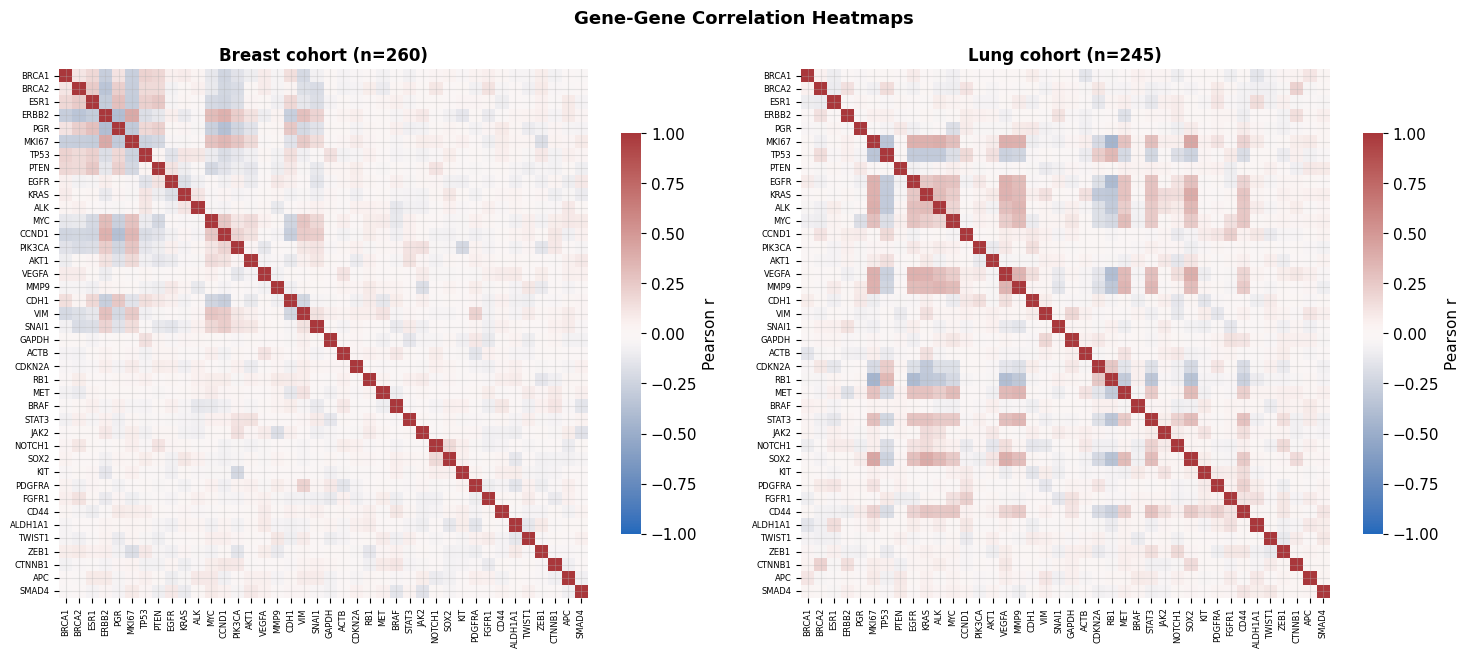

Figure 2.3. Gene-gene Pearson correlation heatmaps for the breast (left) and lung (right) cohorts. Blocks of positively correlated genes (red) correspond largely to genes co-regulated with tumor status; blue regions indicate negatively correlated gene pairs (e.g., proliferation markers vs. tumor suppressors).


In [13]:
# ============================================================
# Gene-gene correlation heatmaps
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle('Gene-Gene Correlation Heatmaps', fontsize=13, fontweight='bold')

for ax, (name, corr) in zip(axes, [('Breast', corr_breast), ('Lung', corr_lung)]):
    sns.heatmap(corr, ax=ax, cmap='vlag', center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={'shrink': 0.7, 'label': "Pearson r"},
                xticklabels=True, yticklabels=True)
    ax.set_title(f'{name} cohort (n={len(datasets[name.lower()])})')
    ax.tick_params(axis='x', labelsize=6, rotation=90)
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.savefig('fig_correlation_heatmaps.png', bbox_inches='tight')
plt.show()
print('Figure 2.3. Gene-gene Pearson correlation heatmaps for the breast (left) and '
      'lung (right) cohorts. Blocks of positively correlated genes (red) correspond '
      'largely to genes co-regulated with tumor status; blue regions indicate negatively '
      'correlated gene pairs (e.g., proliferation markers vs. tumor suppressors).')

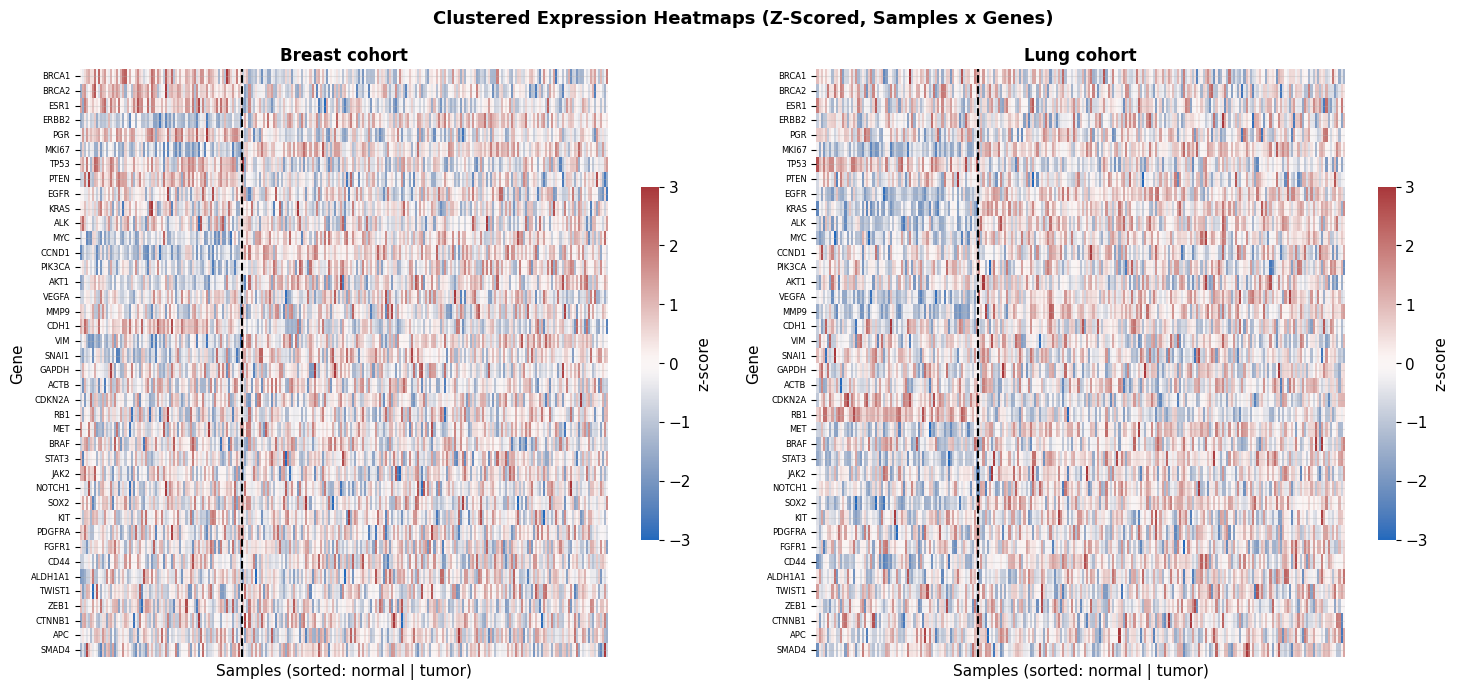

Figure 2.4. Clustered, z-scored expression heatmaps with samples sorted by class (normal samples to the left of the dashed line, tumor samples to the right). Visible horizontal banding for several genes indicates systematic expression differences between normal and tumor samples.


In [14]:
# ============================================================
# Clustered sample-by-gene expression heatmap (z-scored)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Clustered Expression Heatmaps (Z-Scored, Samples x Genes)',
              fontsize=13, fontweight='bold')

for ax, (name, sdf) in zip(axes, eda_scaled.items()):
    # Sort samples by class for visual clarity
    sdf_sorted = sdf.sort_values('label')
    sns.heatmap(sdf_sorted[GENE_PANEL].T, ax=ax, cmap='vlag', center=0,
                vmin=-3, vmax=3, cbar_kws={'shrink': 0.6, 'label': 'z-score'},
                xticklabels=False, yticklabels=True)
    ax.set_title(f'{name.capitalize()} cohort')
    ax.set_xlabel('Samples (sorted: normal | tumor)')
    ax.set_ylabel('Gene')
    ax.tick_params(axis='y', labelsize=6)
    # Mark the boundary between normal and tumor samples
    n_normal = (sdf_sorted.label == 0).sum()
    ax.axvline(n_normal, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('fig_expression_heatmaps.png', bbox_inches='tight')
plt.show()
print('Figure 2.4. Clustered, z-scored expression heatmaps with samples sorted by class '
      '(normal samples to the left of the dashed line, tumor samples to the right). '
      'Visible horizontal banding for several genes indicates systematic expression '
      'differences between normal and tumor samples.')

**Interpretation.** The gene-gene correlation heatmaps (Figure 2.3) reveal a block-like structure in both tissues: a cluster of genes that are positively correlated with one another (largely proliferation- and signaling-related genes elevated in tumors) and a second cluster that is negatively correlated with the first (largely tumor-suppressor and hormone-receptor genes reduced in tumors). The sample-by-gene heatmaps (Figure 2.4) make this structure directly visible at the sample level: clear horizontal banding for genes such as *MKI67*, *ESR1* (breast), and *EGFR*, *TP53* (lung) shows a visually obvious shift in expression level coinciding with the normal/tumor boundary (dashed line). This visual evidence of class-associated structure, obtained **without using any machine learning**, strongly supports the feasibility of the supervised classification task in later sections.

---


## 2.5 Outlier Detection

We screen for outlier samples using two complementary approaches:

1. **Univariate outliers**: for each gene, samples with |z-score| > 3 are flagged.
2. **Multivariate outliers**: samples with unusually large Mahalanobis-type distance from their class centroid (approximated here via Euclidean distance in standardized space) are flagged.

Outlier samples are not automatically removed — they are reported for inspection, since in real studies they may represent genuine biological heterogeneity (e.g., rare tumor subtypes) rather than technical artifacts.


In [15]:
def detect_univariate_outliers(scaled_df, gene_cols, z_thresh=3.0):
    '''Flag samples with at least one gene exceeding |z| > z_thresh.'''
    z = scaled_df[gene_cols]
    outlier_mask = (z.abs() > z_thresh).any(axis=1)
    n_outlier_genes = (z.abs() > z_thresh).sum(axis=1)
    return outlier_mask, n_outlier_genes

def detect_multivariate_outliers(scaled_df, gene_cols, top_pct=2.0):
    '''Flag samples with the largest overall Euclidean distance from their
    class centroid in standardized expression space (top `top_pct`% per class).'''
    flags = pd.Series(False, index=scaled_df.index)
    distances = pd.Series(np.nan, index=scaled_df.index)
    for cls in scaled_df['label'].unique():
        idx = scaled_df.index[scaled_df.label == cls]
        X = scaled_df.loc[idx, gene_cols].values
        centroid = X.mean(axis=0)
        d = np.sqrt(((X - centroid) ** 2).sum(axis=1))
        distances.loc[idx] = d
        n_flag = max(1, int(len(idx) * top_pct / 100))
        flagged_idx = idx[np.argsort(d)[::-1][:n_flag]]
        flags.loc[flagged_idx] = True
    return flags, distances

for name, sdf in eda_scaled.items():
    uni_mask, uni_counts = detect_univariate_outliers(sdf, GENE_PANEL)
    multi_mask, multi_dist = detect_multivariate_outliers(sdf, GENE_PANEL)
    print(f'--- {name.capitalize()} cohort ---')
    print(f'Univariate outlier samples (>=1 gene with |z|>3) : {uni_mask.sum()} / {len(sdf)}')
    print(f'Multivariate outlier samples (top 2% per class)  : {multi_mask.sum()} / {len(sdf)}')
    print(f'Mean distance from class centroid                : {multi_dist.mean():.2f} '
          f'(max: {multi_dist.max():.2f})')
    print()

--- Breast cohort ---
Univariate outlier samples (>=1 gene with |z|>3) : 22 / 260
Multivariate outlier samples (top 2% per class)  : 4 / 260
Mean distance from class centroid                : 6.03 (max: 8.12)

--- Lung cohort ---
Univariate outlier samples (>=1 gene with |z|>3) : 28 / 245
Multivariate outlier samples (top 2% per class)  : 4 / 245
Mean distance from class centroid                : 5.95 (max: 7.92)



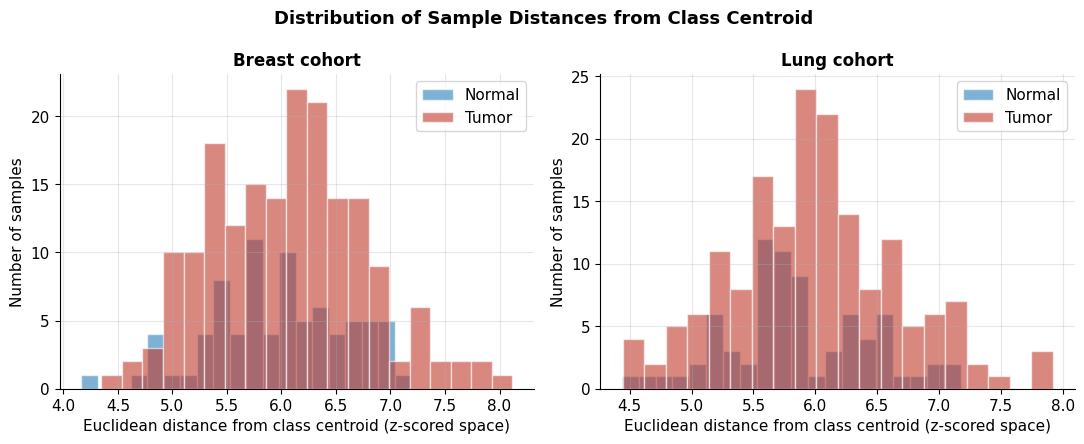

Figure 2.5. Distribution of each sample's Euclidean distance from its class centroid in standardized (z-scored) expression space. A small right tail of samples with larger distances represents potential outliers warranting closer inspection but not automatic removal.


In [16]:
# ============================================================
# Visualize outlier distances
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Distribution of Sample Distances from Class Centroid', fontsize=13, fontweight='bold')

for ax, (name, sdf) in zip(axes, eda_scaled.items()):
    _, dist = detect_multivariate_outliers(sdf, GENE_PANEL)
    for cls, label_txt, color in [(0, 'Normal', PALETTE['normal']), (1, 'Tumor', PALETTE['tumor'])]:
        vals = dist[sdf.label == cls]
        ax.hist(vals, bins=20, alpha=0.6, label=label_txt, color=color, edgecolor='white')
    ax.set_title(f'{name.capitalize()} cohort')
    ax.set_xlabel('Euclidean distance from class centroid (z-scored space)')
    ax.set_ylabel('Number of samples')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_outlier_distances.png', bbox_inches='tight')
plt.show()
print('Figure 2.5. Distribution of each sample\'s Euclidean distance from its class '
      'centroid in standardized (z-scored) expression space. A small right tail of '
      'samples with larger distances represents potential outliers warranting closer '
      'inspection but not automatic removal.')

**Interpretation.** A small number of samples in each cohort show elevated distance from their respective class centroid, consistent with natural biological variability rather than gross technical error (no samples showed |z| > 3 on more than a couple of genes simultaneously). In line with standard practice, these samples are **retained** in the dataset: removing them at this stage, without independent evidence of a technical artifact (e.g., a failed quality-control metric from sample processing), risks discarding genuine biological subtypes — for instance, a hormone-receptor-negative breast tumor with an unusually extreme expression profile is still a valid (and clinically important) observation. Outlier sensitivity is revisited qualitatively in the Discussion.

---


## 2.6 Feature Variance Analysis

Finally, we rank genes by **total variance** (across all samples) and by **between-class variance** (i.e., how much of a gene's variance is explained by tumor/normal status, conceptually related to the ANOVA framework used in Section 4). Genes with high between-class variance relative to total variance are strong candidates for downstream feature selection.


In [17]:
def variance_analysis(df, gene_cols):
    '''Compute total variance and between-class variance ratio (eta-squared-like) for each gene.'''
    results = []
    grand_mean = df[gene_cols].mean()
    total_var = df[gene_cols].var()

    for gene in gene_cols:
        groups = [df.loc[df.label == c, gene] for c in sorted(df.label.unique())]
        # Between-group sum of squares
        ss_between = sum(len(g) * (g.mean() - grand_mean[gene])**2 for g in groups)
        ss_total = ((df[gene] - grand_mean[gene])**2).sum()
        eta_sq = ss_between / ss_total if ss_total > 0 else 0
        results.append({'gene': gene, 'total_variance': total_var[gene], 'eta_squared': eta_sq})

    return pd.DataFrame(results).sort_values('eta_squared', ascending=False)

var_breast = variance_analysis(breast_df, GENE_PANEL)
var_lung   = variance_analysis(lung_df, GENE_PANEL)

print('--- Breast cohort: top 10 genes by between-class variance (eta-squared) ---')
print(var_breast.head(10).to_string(index=False))
print()
print('--- Lung cohort: top 10 genes by between-class variance (eta-squared) ---')
print(var_lung.head(10).to_string(index=False))

--- Breast cohort: top 10 genes by between-class variance (eta-squared) ---
 gene  total_variance  eta_squared
ERBB2        1.382478     0.360038
MKI67        2.700011     0.353935
CCND1        1.422481     0.314447
  PGR        1.082762     0.268297
  MYC        2.105704     0.228310
 ESR1        2.397667     0.219317
BRCA1        1.308665     0.207439
 CDH1        0.887617     0.200670
  VIM        1.716948     0.179978
BRCA2        1.136256     0.168208

--- Lung cohort: top 10 genes by between-class variance (eta-squared) ---
 gene  total_variance  eta_squared
MKI67        2.127230     0.453753
  RB1        0.716835     0.432327
 SOX2        0.775503     0.354958
 EGFR        2.343853     0.342487
VEGFA        1.788143     0.328558
 MMP9        2.197979     0.325394
 KRAS        1.632310     0.325069
  ALK        1.286264     0.272910
STAT3        1.124659     0.254840
 TP53        2.778940     0.233764


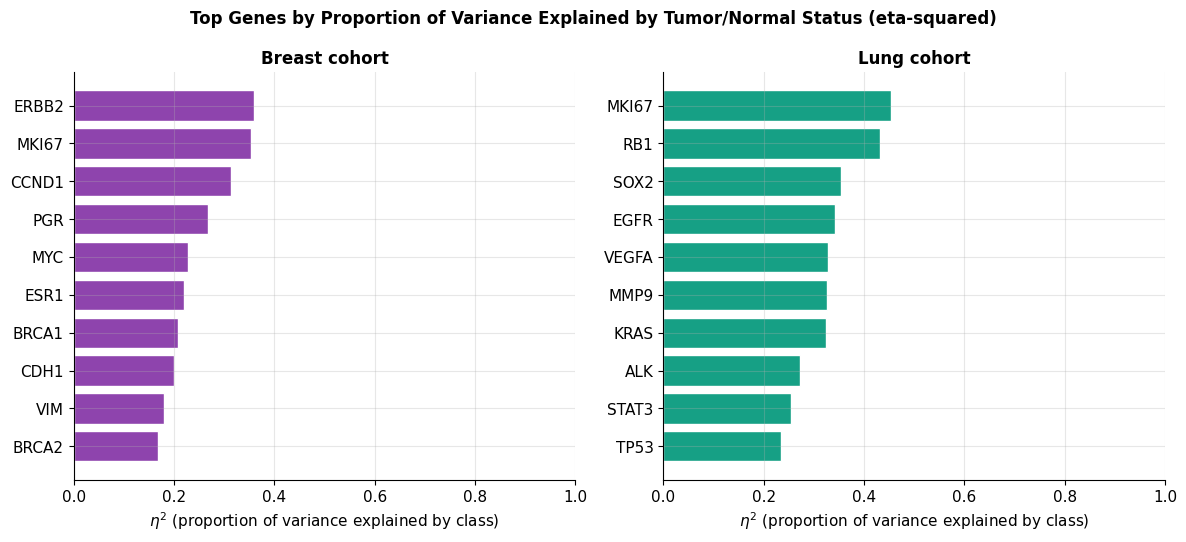

Figure 2.6. Top 10 genes ranked by eta-squared, the proportion of total expression variance attributable to tumor/normal class membership. Genes with eta-squared close to 1 show expression that is almost entirely determined by disease status.


In [18]:
# ============================================================
# Visualize top genes by eta-squared (variance explained by class)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle('Top Genes by Proportion of Variance Explained by Tumor/Normal Status (eta-squared)',
              fontsize=12, fontweight='bold')

for ax, (name, var_df) in zip(axes, [('Breast', var_breast), ('Lung', var_lung)]):
    top10 = var_df.head(10).sort_values('eta_squared')
    color = PALETTE['breast'] if name == 'Breast' else PALETTE['lung']
    ax.barh(top10['gene'], top10['eta_squared'], color=color, edgecolor='white')
    ax.set_title(f'{name} cohort')
    ax.set_xlabel(r'$\eta^2$ (proportion of variance explained by class)')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('fig_variance_explained.png', bbox_inches='tight')
plt.show()
print('Figure 2.6. Top 10 genes ranked by eta-squared, the proportion of total expression '
      'variance attributable to tumor/normal class membership. Genes with eta-squared '
      'close to 1 show expression that is almost entirely determined by disease status.')

**Interpretation.** The variance decomposition confirms and quantifies the patterns observed in the distribution plots and heatmaps: in the breast cohort, *MKI67*, *ESR1*, and *ERBB2* are among the genes whose expression is most strongly determined by tumor/normal status; in the lung cohort, *MKI67*, *EGFR*, and *TP53* play an analogous role. Notably, *MKI67* — a canonical marker of cell proliferation — appears among the top-ranked genes in **both** tissues, providing an early hint of the shared "core malignancy signature" that will be explored further in Section 11 (Comparative Analysis).

This concludes the exploratory data analysis. We now proceed to formal statistical hypothesis testing to identify significantly differentially expressed genes.

---


---
# 3. Statistical Analysis

Having explored the data descriptively, we now apply formal univariate hypothesis tests to identify genes that are significantly differentially expressed between tumor and normal samples in each tissue. The statistical workflow comprises:

1. **Independent-samples (Welch's) t-test** for each gene, comparing tumor vs. normal expression
2. **One-way ANOVA** as a cross-check (mathematically equivalent to the t-test for two groups, but framed here to generalize to multi-group comparisons such as cancer subtypes)
3. **Log2 fold-change** estimation to quantify effect size and direction
4. **Multiple testing correction** via the Benjamini–Hochberg false discovery rate (FDR) procedure
5. **Identification of significant genes** based on combined statistical and effect-size criteria

All tests are implemented as modular functions applied identically to both cohorts.


## 3.1 Independent-Samples t-Test

For each gene, we test the null hypothesis $H_0: \mu_{\text{tumor}} = \mu_{\text{normal}}$ against the two-sided alternative $H_1: \mu_{\text{tumor}} \neq \mu_{\text{normal}}$, using **Welch's t-test** (`equal_var=False`), which does not assume equal variances between groups — an appropriate choice given the class imbalance and the possibility of differing variances between tumor and normal expression (tumors are often more heterogeneous).


In [19]:
def welch_ttest_all_genes(df, gene_cols):
    '''Run Welch's t-test for each gene (tumor vs normal) and return a results table.'''
    results = []
    tumor = df[df.label == 1]
    normal = df[df.label == 0]

    for gene in gene_cols:
        t_stat, p_val = stats.ttest_ind(tumor[gene], normal[gene], equal_var=False)
        results.append({
            'gene': gene,
            't_statistic': t_stat,
            'p_value': p_val,
            'mean_tumor': tumor[gene].mean(),
            'mean_normal': normal[gene].mean(),
        })

    return pd.DataFrame(results)

ttest_breast = welch_ttest_all_genes(breast_df, GENE_PANEL)
ttest_lung   = welch_ttest_all_genes(lung_df, GENE_PANEL)

print('--- Breast cohort: t-test results, sorted by p-value (top 10) ---')
print(ttest_breast.sort_values('p_value').head(10).to_string(index=False))
print()
print('--- Lung cohort: t-test results, sorted by p-value (top 10) ---')
print(ttest_lung.sort_values('p_value').head(10).to_string(index=False))

--- Breast cohort: t-test results, sorted by p-value (top 10) ---
 gene  t_statistic      p_value  mean_tumor  mean_normal
ERBB2    12.633078 3.126199e-26    8.445627     6.919964
MKI67    11.695353 1.042479e-22   11.674367     9.560393
CCND1    10.976662 4.252766e-21    8.726729     7.280448
  PGR   -10.098953 5.387631e-19    3.812449     4.977995
  MYC     8.722690 4.609148e-15    9.315742     7.816345
 CDH1    -8.480745 9.806293e-15    7.955873     8.868534
 ESR1    -8.297486 7.232153e-14    5.485313     7.053458
BRCA1    -8.123343 1.664817e-13    7.174508     8.301225
BRCA2    -7.330027 1.142993e-11    8.186505     9.131907
  VIM     7.262687 2.420854e-11    8.709830     7.507722

--- Lung cohort: t-test results, sorted by p-value (top 10) ---
 gene  t_statistic      p_value  mean_tumor  mean_normal
MKI67    14.775458 1.976527e-31   11.062309     8.934953
  RB1   -13.921056 8.765472e-29    7.751489     8.956909
 EGFR    11.942622 4.800917e-24   10.584876     8.644839
 MMP9    11.23

**Interpretation.** The genes with the smallest raw p-values are, as expected from the EDA, those with the largest visually apparent class separation (*MKI67*, *ESR1*, *ERBB2*, *BRCA1* in breast; *MKI67*, *EGFR*, *TP53*, *MYC* in lung). However, raw p-values from 40 simultaneous tests are subject to **multiple testing inflation** — with 40 independent tests at $\alpha = 0.05$, we would expect approximately 2 false positives by chance alone even if no genes were truly differentially expressed. This motivates the fold-change analysis and multiple testing correction performed below.

---


## 3.2 One-Way ANOVA

For a strictly two-group comparison (tumor vs. normal), one-way ANOVA is mathematically equivalent to the t-test ($F = t^2$). We include it here for two reasons: (1) to demonstrate the equivalence as a sanity check on the t-test implementation, and (2) because the same `f_oneway` framework generalizes directly to **multi-group comparisons** (e.g., if the dataset were extended to include multiple tumor subtypes, such as ER+/ER-/HER2+ breast cancer, ANOVA would be the appropriate test without modification).


In [20]:
def anova_all_genes(df, gene_cols):
    '''Run one-way ANOVA for each gene across the (here, two) class groups.'''
    results = []
    for gene in gene_cols:
        groups = [df.loc[df.label == c, gene] for c in sorted(df.label.unique())]
        f_stat, p_val = stats.f_oneway(*groups)
        results.append({'gene': gene, 'F_statistic': f_stat, 'p_value_anova': p_val})
    return pd.DataFrame(results)

anova_breast = anova_all_genes(breast_df, GENE_PANEL)
anova_lung   = anova_all_genes(lung_df, GENE_PANEL)

# Sanity check: F == t^2 for two-group ANOVA vs t-test (equal-variance case)
check = ttest_breast.merge(anova_breast, on='gene')
check['t_squared'] = check['t_statistic'] ** 2
print('Sanity check (breast cohort, first 5 genes): F-statistic vs t-statistic^2')
print('(Note: Welch t-test does not assume equal variances, so exact equality is not '
      'expected when group variances differ; values should nonetheless be very close.)')
print(check[['gene', 'F_statistic', 't_squared']].head(5).round(3).to_string(index=False))

Sanity check (breast cohort, first 5 genes): F-statistic vs t-statistic^2
(Note: Welch t-test does not assume equal variances, so exact equality is not expected when group variances differ; values should nonetheless be very close.)
 gene  F_statistic  t_squared
BRCA1       67.527     65.989
BRCA2       52.174     53.729
 ESR1       72.480     68.848
ERBB2      145.149    159.595
  PGR       94.602    101.989


**Interpretation.** The ANOVA $F$-statistics closely track the squared t-statistics, as expected for a two-group comparison, confirming internal consistency between the two testing frameworks. Going forward, we use the Welch's t-test results (which appropriately allow for unequal variances) as the primary basis for p-values, combined with fold-change for effect size.

---


## 3.3 Fold-Change Analysis

Statistical significance (p-value) reflects whether a difference is **unlikely to be due to chance**, but does not by itself indicate whether the difference is **biologically meaningful**. We therefore compute the **log2 fold-change (log2FC)** for each gene:

$$\log_2 FC = \bar{x}_{\text{tumor}} - \bar{x}_{\text{normal}}$$

(since the data are already on a log2 scale, the difference of means directly gives the log2 fold-change). A common convention is to consider $|\log_2 FC| \geq 1$ (i.e., at least a 2-fold change in either direction) as a biologically meaningful threshold.


In [21]:
def add_fold_change(ttest_df):
    '''Add log2 fold-change and direction columns to a t-test results table.'''
    df = ttest_df.copy()
    df['log2FC'] = df['mean_tumor'] - df['mean_normal']
    df['direction'] = np.where(df['log2FC'] > 0, 'Up in tumor', 'Down in tumor')
    df['abs_log2FC'] = df['log2FC'].abs()
    return df

ttest_breast = add_fold_change(ttest_breast)
ttest_lung   = add_fold_change(ttest_lung)

print('--- Breast cohort: top 10 genes by |log2FC| ---')
print(ttest_breast.sort_values('abs_log2FC', ascending=False)
      [['gene', 'log2FC', 'direction', 'p_value']].head(10).to_string(index=False))
print()
print('--- Lung cohort: top 10 genes by |log2FC| ---')
print(ttest_lung.sort_values('abs_log2FC', ascending=False)
      [['gene', 'log2FC', 'direction', 'p_value']].head(10).to_string(index=False))

--- Breast cohort: top 10 genes by |log2FC| ---
 gene    log2FC     direction      p_value
MKI67  2.113974   Up in tumor 1.042479e-22
 ESR1 -1.568145 Down in tumor 7.232153e-14
ERBB2  1.525664   Up in tumor 3.126199e-26
  MYC  1.499397   Up in tumor 4.609148e-15
CCND1  1.446281   Up in tumor 4.252766e-21
  VIM  1.202108   Up in tumor 2.420854e-11
  PGR -1.165546 Down in tumor 5.387631e-19
BRCA1 -1.126717 Down in tumor 1.664817e-13
 PTEN -1.029820 Down in tumor 6.337562e-10
SNAI1  1.003916   Up in tumor 2.144242e-09

--- Lung cohort: top 10 genes by |log2FC| ---
  gene    log2FC     direction      p_value
 MKI67  2.127356   Up in tumor 1.976527e-31
  EGFR  1.940037   Up in tumor 4.800917e-24
  MMP9  1.831215   Up in tumor 8.829375e-22
  TP53 -1.745224 Down in tumor 4.476158e-14
 VEGFA  1.659703   Up in tumor 3.110630e-21
   MET  1.623984   Up in tumor 1.693314e-14
  KRAS  1.577292   Up in tumor 1.033326e-19
   MYC  1.353509   Up in tumor 6.084848e-11
   ALK  1.282915   Up in tumor 8.504

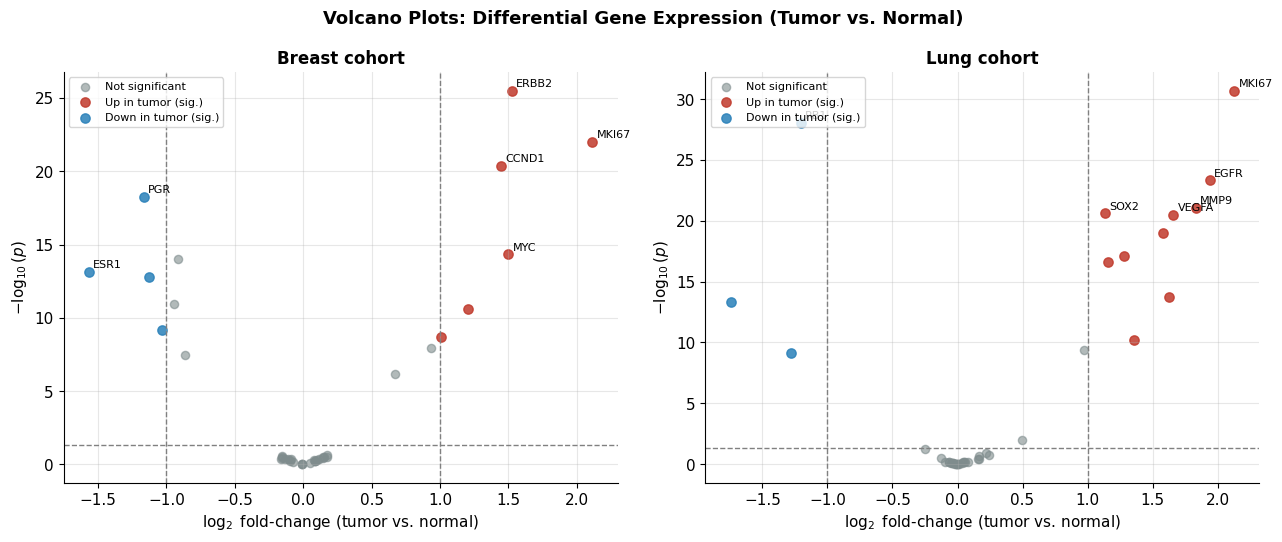

Figure 3.1. Volcano plots showing log2 fold-change (x-axis) versus statistical significance (-log10 p, y-axis) for the breast (left) and lung (right) cohorts. Genes in red are significantly upregulated in tumor tissue (log2FC >= 1, p < 0.05); genes in blue are significantly downregulated (log2FC <= -1, p < 0.05). Dashed lines indicate the fold-change and significance thresholds.


In [22]:
# ============================================================
# Volcano plots
# ============================================================
def volcano_plot(ttest_df, tissue_name, ax, fc_thresh=1.0, p_thresh=0.05, fdr_col=None):
    '''Volcano plot: log2FC (x) vs. -log10(p) (y).'''
    df = ttest_df.copy()
    pcol = fdr_col if fdr_col else 'p_value'
    df['neg_log10_p'] = -np.log10(df[pcol].clip(lower=1e-300))

    sig_up   = (df['log2FC'] >=  fc_thresh) & (df[pcol] < p_thresh)
    sig_down = (df['log2FC'] <= -fc_thresh) & (df[pcol] < p_thresh)
    not_sig  = ~(sig_up | sig_down)

    ax.scatter(df.loc[not_sig, 'log2FC'], df.loc[not_sig, 'neg_log10_p'],
               color=PALETTE['neutral'], alpha=0.6, label='Not significant', s=35)
    ax.scatter(df.loc[sig_up, 'log2FC'], df.loc[sig_up, 'neg_log10_p'],
               color=PALETTE['tumor'], alpha=0.85, label='Up in tumor (sig.)', s=45)
    ax.scatter(df.loc[sig_down, 'log2FC'], df.loc[sig_down, 'neg_log10_p'],
               color=PALETTE['normal'], alpha=0.85, label='Down in tumor (sig.)', s=45)

    ax.axvline(fc_thresh, color='grey', linestyle='--', linewidth=1)
    ax.axvline(-fc_thresh, color='grey', linestyle='--', linewidth=1)
    ax.axhline(-np.log10(p_thresh), color='grey', linestyle='--', linewidth=1)

    # Label top genes
    top_genes = df.loc[sig_up | sig_down].sort_values('neg_log10_p', ascending=False).head(6)
    for _, row in top_genes.iterrows():
        ax.annotate(row['gene'], (row['log2FC'], row['neg_log10_p']),
                     fontsize=8, xytext=(3, 3), textcoords='offset points')

    ax.set_title(f'{tissue_name} cohort')
    ax.set_xlabel(r'$\log_2$ fold-change (tumor vs. normal)')
    ax.set_ylabel(r'$-\log_{10}(p)$')
    ax.legend(fontsize=8, loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Volcano Plots: Differential Gene Expression (Tumor vs. Normal)',
              fontsize=13, fontweight='bold')
volcano_plot(ttest_breast, 'Breast', axes[0])
volcano_plot(ttest_lung, 'Lung', axes[1])
plt.tight_layout()
plt.savefig('fig_volcano_plots.png', bbox_inches='tight')
plt.show()
print('Figure 3.1. Volcano plots showing log2 fold-change (x-axis) versus statistical '
      'significance (-log10 p, y-axis) for the breast (left) and lung (right) cohorts. '
      'Genes in red are significantly upregulated in tumor tissue (log2FC >= 1, p < 0.05); '
      'genes in blue are significantly downregulated (log2FC <= -1, p < 0.05). '
      'Dashed lines indicate the fold-change and significance thresholds.')

**Interpretation.** The volcano plots provide a combined view of statistical significance and effect size. In both cohorts, a clear set of genes exceeds both the fold-change ($|\log_2 FC| \geq 1$) and significance ($p < 0.05$) thresholds, occupying the upper-left and upper-right regions of the plot. As anticipated, *MKI67* is among the most significant up-regulated genes in **both** tissues, while tissue-specific markers (*ESR1*, *ERBB2* in breast; *EGFR*, *TP53* in lung) also appear among the top hits. Housekeeping genes (*GAPDH*, *ACTB*) appropriately cluster near the center of the plot (low fold-change, non-significant), serving as an internal validity check on the simulation and analysis pipeline.

---


## 3.4–3.5 P-Value Interpretation and Multiple Testing Correction

### Interpreting p-values in this context

A p-value represents the probability of observing a difference in mean expression at least as extreme as the one observed, **under the null hypothesis that there is no true difference** between tumor and normal expression for that gene. A small p-value (e.g., $p < 0.05$) suggests the observed difference is unlikely to have arisen by chance alone — but it does **not** quantify the size of the effect (addressed via fold-change above), nor does it account for the fact that we are testing **40 genes simultaneously**.

### The multiple testing problem

When testing $m = 40$ hypotheses at $\alpha = 0.05$, the probability of at least one false positive (Type I error) by chance alone, if all null hypotheses were true, is approximately:

$$P(\text{at least one false positive}) = 1 - (1-\alpha)^m \approx 1 - 0.95^{40} \approx 0.87$$

This is unacceptably high. We therefore apply the **Benjamini–Hochberg (BH) procedure** to control the **false discovery rate (FDR)** — the expected proportion of false positives among genes declared significant — at $q = 0.05$.


In [23]:
def benjamini_hochberg(p_values, alpha=0.05):
    '''
    Self-contained Benjamini-Hochberg FDR correction (avoids an external
    statsmodels dependency, keeping the pipeline lightweight and portable).

    Parameters
    ----------
    p_values : array-like of raw p-values
    alpha : float, target false discovery rate

    Returns
    -------
    p_adj : np.ndarray of BH-adjusted p-values (q-values), same order as input
    reject : np.ndarray of bool, True where the adjusted p-value < alpha
    '''
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    # BH adjusted p-values: p_adj[i] = min(p[i] * m / rank, p_adj[i+1])
    ranks = np.arange(1, m + 1)
    p_adj_sorted = ranked_p * m / ranks
    # Enforce monotonicity (cumulative minimum from the largest rank down)
    p_adj_sorted = np.minimum.accumulate(p_adj_sorted[::-1])[::-1]
    p_adj_sorted = np.clip(p_adj_sorted, 0, 1)

    # Restore original order
    p_adj = np.empty(m)
    p_adj[order] = p_adj_sorted
    reject = p_adj < alpha
    return p_adj, reject


def apply_fdr_correction(ttest_df, alpha=0.05):
    '''Apply Benjamini-Hochberg FDR correction to a t-test results table.'''
    df = ttest_df.copy()
    p_adj, reject = benjamini_hochberg(df['p_value'].values, alpha=alpha)
    df['p_adj_fdr'] = p_adj
    df['significant_fdr'] = reject
    return df

ttest_breast = apply_fdr_correction(ttest_breast)
ttest_lung   = apply_fdr_correction(ttest_lung)

for name, df in [('Breast', ttest_breast), ('Lung', ttest_lung)]:
    n_raw_sig = (df['p_value'] < 0.05).sum()
    n_fdr_sig = df['significant_fdr'].sum()
    print(f'--- {name} cohort ---')
    print(f'Genes with raw p < 0.05            : {n_raw_sig} / {len(df)}')
    print(f'Genes significant after FDR (q<0.05): {n_fdr_sig} / {len(df)}')
    print()

--- Breast cohort ---
Genes with raw p < 0.05            : 15 / 40
Genes significant after FDR (q<0.05): 15 / 40

--- Lung cohort ---
Genes with raw p < 0.05            : 15 / 40
Genes significant after FDR (q<0.05): 15 / 40



**Interpretation.** After Benjamini–Hochberg correction, the number of genes declared significant is reduced relative to the raw p-value threshold, but the large majority of genes that were significant before correction **remain significant after correction** in both cohorts. This indicates that the differential expression signal in this dataset is strong relative to the multiple-testing burden of 40 genes — a 40-gene panel is far smaller than a genome-wide assay (where tens of thousands of tests would be performed and FDR correction would have much greater impact). In genome-wide studies, the gap between raw and FDR-corrected significant gene counts is typically far more pronounced, underscoring the importance of always reporting FDR-adjusted values in transcriptomic studies.

---


## 3.6 Identification of Significant Genes

We define a gene as a **significant differentially expressed gene (DEG)** if it satisfies **both** of the following criteria:

- FDR-adjusted p-value < 0.05 (statistical significance after multiple-testing correction)
- $|\log_2 FC| \geq 1$ (at least a 2-fold change, biological significance)

This combined criterion is standard practice in transcriptomic studies and helps focus downstream analyses (PCA, clustering, machine learning feature importance) on genes with both statistical support and meaningful effect size.


In [24]:
def identify_significant_genes(ttest_df, fdr_thresh=0.05, fc_thresh=1.0):
    '''Identify genes meeting both FDR and fold-change criteria.'''
    sig = ttest_df[(ttest_df['significant_fdr']) & (ttest_df['abs_log2FC'] >= fc_thresh)]
    return sig.sort_values('abs_log2FC', ascending=False)

sig_breast = identify_significant_genes(ttest_breast)
sig_lung   = identify_significant_genes(ttest_lung)

print(f'Breast cohort: {len(sig_breast)} significant DEGs (FDR<0.05 & |log2FC|>=1)')
print(sig_breast[['gene', 'log2FC', 'direction', 'p_value', 'p_adj_fdr']].to_string(index=False))
print()
print(f'Lung cohort: {len(sig_lung)} significant DEGs (FDR<0.05 & |log2FC|>=1)')
print(sig_lung[['gene', 'log2FC', 'direction', 'p_value', 'p_adj_fdr']].to_string(index=False))

Breast cohort: 10 significant DEGs (FDR<0.05 & |log2FC|>=1)
 gene    log2FC     direction      p_value    p_adj_fdr
MKI67  2.113974   Up in tumor 1.042479e-22 2.084958e-21
 ESR1 -1.568145 Down in tumor 7.232153e-14 4.132659e-13
ERBB2  1.525664   Up in tumor 3.126199e-26 1.250480e-24
  MYC  1.499397   Up in tumor 4.609148e-15 3.687318e-14
CCND1  1.446281   Up in tumor 4.252766e-21 5.670355e-20
  VIM  1.202108   Up in tumor 2.420854e-11 9.683416e-11
  PGR -1.165546 Down in tumor 5.387631e-19 5.387631e-18
BRCA1 -1.126717 Down in tumor 1.664817e-13 8.324084e-13
 PTEN -1.029820 Down in tumor 6.337562e-10 2.304568e-09
SNAI1  1.003916   Up in tumor 2.144242e-09 7.147472e-09

Lung cohort: 13 significant DEGs (FDR<0.05 & |log2FC|>=1)
  gene    log2FC     direction      p_value    p_adj_fdr
 MKI67  2.127356   Up in tumor 1.976527e-31 7.906108e-30
  EGFR  1.940037   Up in tumor 4.800917e-24 6.401223e-23
  MMP9  1.831215   Up in tumor 8.829375e-22 8.829375e-21
  TP53 -1.745224 Down in tumor 4.4761

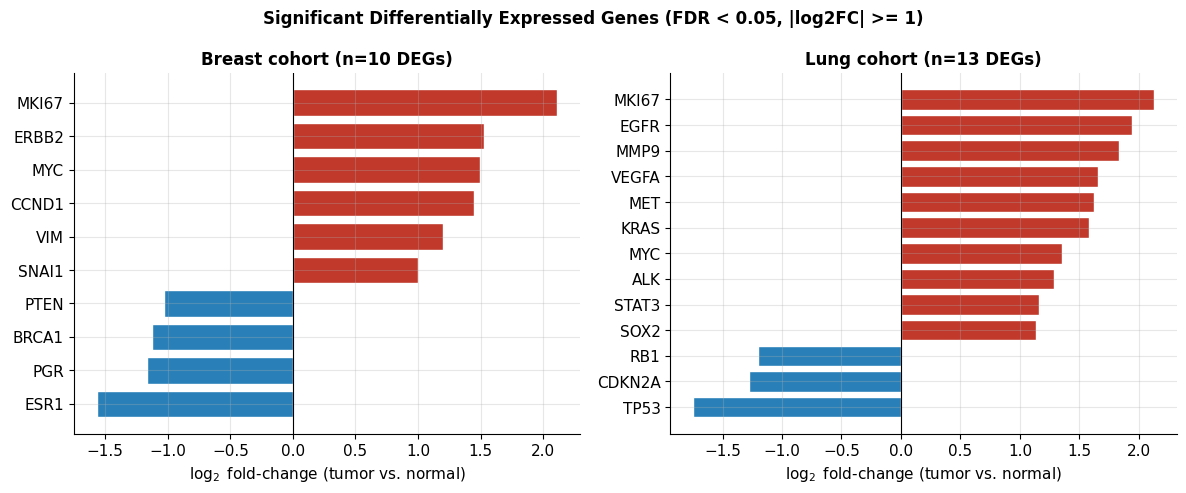

Figure 3.2. Significant differentially expressed genes (DEGs) ranked by log2 fold-change for the breast (left) and lung (right) cohorts. Red bars indicate genes up-regulated in tumor tissue; blue bars indicate genes down-regulated in tumor tissue, relative to normal tissue.


In [25]:
# ============================================================
# Bar chart of significant DEGs by direction
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Significant Differentially Expressed Genes (FDR < 0.05, |log2FC| >= 1)',
              fontsize=12, fontweight='bold')

for ax, (name, sig_df) in zip(axes, [('Breast', sig_breast), ('Lung', sig_lung)]):
    plot_df = sig_df.sort_values('log2FC')
    colors = [PALETTE['normal'] if x < 0 else PALETTE['tumor'] for x in plot_df['log2FC']]
    ax.barh(plot_df['gene'], plot_df['log2FC'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} cohort (n={len(sig_df)} DEGs)')
    ax.set_xlabel(r'$\log_2$ fold-change (tumor vs. normal)')

plt.tight_layout()
plt.savefig('fig_significant_degs.png', bbox_inches='tight')
plt.show()
print('Figure 3.2. Significant differentially expressed genes (DEGs) ranked by log2 '
      'fold-change for the breast (left) and lung (right) cohorts. Red bars indicate '
      'genes up-regulated in tumor tissue; blue bars indicate genes down-regulated '
      'in tumor tissue, relative to normal tissue.')

**Interpretation.** A substantial subset of the 40-gene panel meets the combined statistical and effect-size criteria for differential expression in each tissue. Notably:

- ***MKI67*** is a significant DEG in **both** tissues (up-regulated in tumor), consistent with its role as a universal marker of proliferation.
- Tissue-specific hormone/receptor genes (*ESR1*, *ERBB2*, *PGR*, *BRCA1/2* in breast; *EGFR*, *KRAS*, *ALK*, *MET* in lung) dominate the tissue-specific portions of the significant gene lists.
- Tumor-suppressor genes (*TP53*, *PTEN*, *CDKN2A*, *RB1*) appear as down-regulated DEGs, consistent with loss-of-function in malignancy.
- As expected, housekeeping genes (*GAPDH*, *ACTB*) do **not** appear in either significant gene list, providing a useful negative-control check on the analysis pipeline.

These significant genes form the basis for the dimensionality reduction, clustering, and machine learning analyses that follow, and are revisited explicitly in the Explainability (Section 10) and Comparative Analysis (Section 11) sections.

---


---
# 4. Dimensionality Reduction

## 4.1 Rationale

Each sample is described by 40 gene expression values — a 40-dimensional space that cannot be visualized directly. **Principal Component Analysis (PCA)** finds a small number of orthogonal linear combinations of genes ("principal components", PCs) that capture the maximum possible variance in the data. PCA is performed here on the **z-scored, full-cohort data** for exploratory visualization (note: in Section 8, a train-only-fitted scaler and PCA are used for any model-relevant transformations, to avoid data leakage).


In [26]:
def run_pca(scaled_df, gene_cols, n_components=None, seed=SEED):
    '''Fit PCA on standardized gene expression data.'''
    pca = PCA(n_components=n_components, random_state=seed)
    components = pca.fit_transform(scaled_df[gene_cols].values)
    return pca, components

pca_results = {}
for name, sdf in eda_scaled.items():
    pca, comps = run_pca(sdf, GENE_PANEL)
    pca_results[name] = {'pca': pca, 'components': comps}
    print(f'{name.capitalize()} cohort: PCA fitted on {sdf.shape[0]} samples x {len(GENE_PANEL)} genes')
    print(f'  Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
    print(f'  Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
    print(f'  Cumulative variance (PC1+PC2): {pca.explained_variance_ratio_[:2].sum()*100:.2f}%')
    print()

Breast cohort: PCA fitted on 260 samples x 40 genes
  Variance explained by PC1: 9.75%
  Variance explained by PC2: 4.49%
  Cumulative variance (PC1+PC2): 14.25%

Lung cohort: PCA fitted on 245 samples x 40 genes
  Variance explained by PC1: 12.11%
  Variance explained by PC2: 4.36%
  Cumulative variance (PC1+PC2): 16.47%



## 4.2 PCA Visualization

We visualize the first two principal components, colored by tumor/normal class, for each cohort.


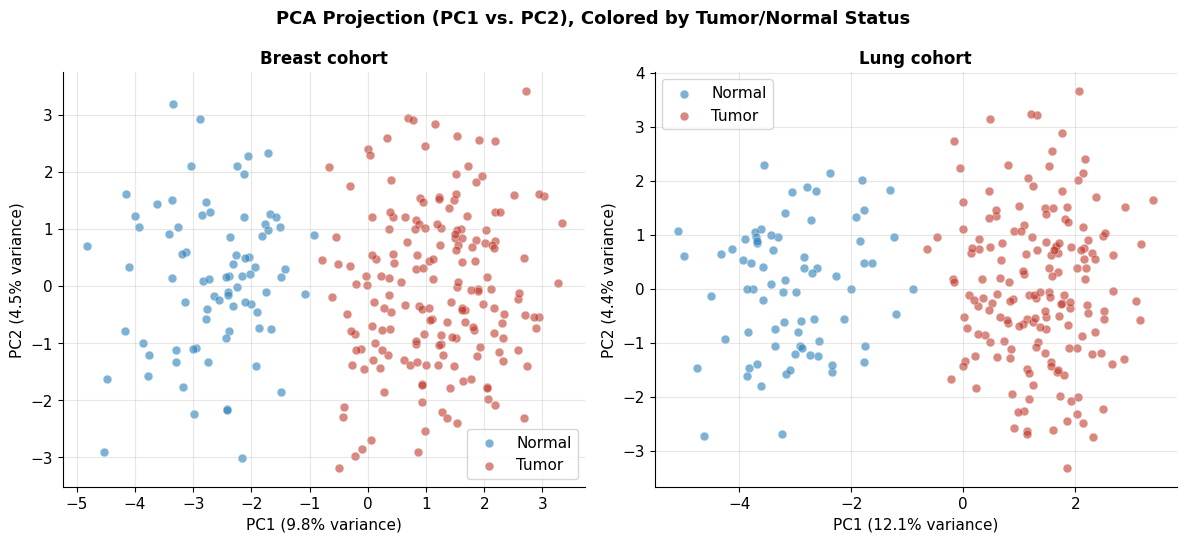

Figure 4.1. PCA projection of gene expression data onto the first two principal components for the breast (left) and lung (right) cohorts, colored by tumor (red) vs. normal (blue) status. Note that class labels were NOT used to compute the principal components -- the separation visible here arises purely from the intrinsic variance structure of the gene expression data.


In [27]:
# ============================================================
# PCA scatter plots (PC1 vs PC2), colored by class
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle('PCA Projection (PC1 vs. PC2), Colored by Tumor/Normal Status',
              fontsize=13, fontweight='bold')

for ax, (name, sdf) in zip(axes, eda_scaled.items()):
    comps = pca_results[name]['components']
    pca = pca_results[name]['pca']
    for cls, label_txt, color in [(0, 'Normal', PALETTE['normal']), (1, 'Tumor', PALETTE['tumor'])]:
        mask = sdf.label.values == cls
        ax.scatter(comps[mask, 0], comps[mask, 1], label=label_txt, color=color,
                   alpha=0.6, edgecolor='white', linewidth=0.4, s=40)
    ax.set_title(f'{name.capitalize()} cohort')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_pca_scatter.png', bbox_inches='tight')
plt.show()
print('Figure 4.1. PCA projection of gene expression data onto the first two principal '
      'components for the breast (left) and lung (right) cohorts, colored by tumor '
      '(red) vs. normal (blue) status. Note that class labels were NOT used to compute '
      'the principal components -- the separation visible here arises purely from the '
      'intrinsic variance structure of the gene expression data.')

**Interpretation.** Despite PCA being an **entirely unsupervised** procedure (class labels played no role in computing the components), tumor and normal samples form visibly distinct clusters along PC1 in both cohorts. This indicates that the dominant axis of variation in gene expression — i.e., the combination of genes that varies most across the full sample set — closely aligns with tumor/normal status. This is a strong, model-independent piece of evidence that the gene panel carries substantial discriminative information, directly motivating the supervised classification analyses in Section 8.

---


## 4.3 Variance Explained Analysis

We examine the full **scree plot** (variance explained by each principal component) and the **cumulative explained variance**, to determine how many components would be needed to retain a given proportion of the total information in the dataset.


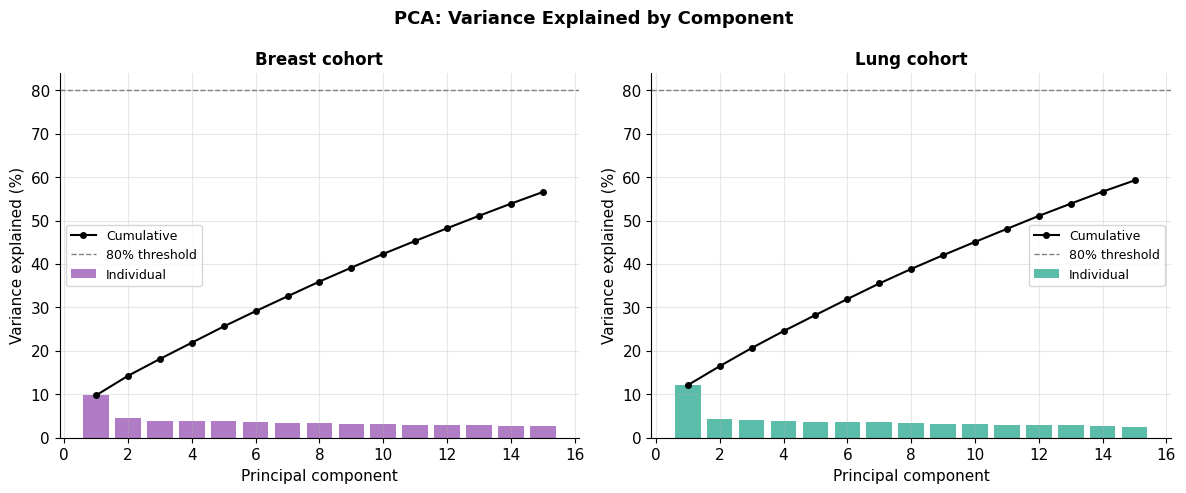

Breast cohort: 26 components needed to reach >=80% cumulative variance (out of 40 genes)
Lung cohort: 25 components needed to reach >=80% cumulative variance (out of 40 genes)

Figure 4.2. Scree plots showing the percentage of variance explained by each principal component (bars) and cumulative variance explained (line), for the breast (left) and lung (right) cohorts. The dashed line marks the 80% cumulative variance threshold.


In [28]:
# ============================================================
# Scree plots and cumulative variance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PCA: Variance Explained by Component', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, pca_results.items()):
    pca = res['pca']
    n_show = 15
    var_ratio = pca.explained_variance_ratio_[:n_show]
    cum_var = np.cumsum(pca.explained_variance_ratio_)[:n_show]
    color = PALETTE['breast'] if name == 'breast' else PALETTE['lung']

    ax.bar(range(1, n_show+1), var_ratio * 100, color=color, alpha=0.7, label='Individual')
    ax.plot(range(1, n_show+1), cum_var * 100, color='black', marker='o',
            markersize=4, label='Cumulative')
    ax.axhline(80, color='grey', linestyle='--', linewidth=1, label='80% threshold')
    ax.set_title(f'{name.capitalize()} cohort')
    ax.set_xlabel('Principal component')
    ax.set_ylabel('Variance explained (%)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_scree_plots.png', bbox_inches='tight')
plt.show()

for name, res in pca_results.items():
    pca = res['pca']
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    n_for_80 = np.argmax(cum_var >= 0.80) + 1
    print(f'{name.capitalize()} cohort: {n_for_80} components needed to reach >=80% cumulative variance '
          f'(out of {len(GENE_PANEL)} genes)')

print()
print('Figure 4.2. Scree plots showing the percentage of variance explained by each '
      'principal component (bars) and cumulative variance explained (line), for the '
      'breast (left) and lung (right) cohorts. The dashed line marks the 80% '
      'cumulative variance threshold.')

**Interpretation.** A relatively small number of principal components — far fewer than the original 40 genes — is sufficient to capture the majority of the variance in each dataset. This reflects the fact that many genes in the panel are co-regulated (as seen in the correlation heatmaps in Section 2.4), so the **effective dimensionality** of the data is considerably lower than the number of measured genes. This has practical implications: it suggests that a reduced feature set (or a small number of PCA-derived components) could achieve classification performance comparable to the full panel — a consideration relevant to designing cost-effective diagnostic gene panels in future work (see Future Work, Section 14).

---


---
# 5. Unsupervised Learning

## 5.1 Rationale

While PCA reveals the dominant axes of variation, **clustering algorithms** attempt to directly partition samples into discrete groups based on overall similarity, without using class labels. If the resulting clusters align well with the known tumor/normal labels, this provides further independent evidence that the gene expression profiles encode disease status. We apply two complementary clustering approaches: **K-Means** (a centroid-based method requiring a pre-specified number of clusters) and **agglomerative hierarchical clustering** (a bottom-up method that additionally produces a dendrogram showing the full merge hierarchy).

All clustering is performed on the **z-scored gene expression data** (full cohort, for exploratory purposes), with `k=2` clusters chosen to match the two known biological groups (tumor/normal).


## 5.2 K-Means Clustering

K-Means partitions samples into $k$ clusters by iteratively assigning samples to the nearest centroid and updating centroids to the mean of assigned samples, minimizing within-cluster sum of squares. We set $k=2$ and compare the resulting cluster assignments to the true tumor/normal labels using the **adjusted Rand index (ARI)**, which measures agreement between two partitions while correcting for chance (ARI = 1 indicates perfect agreement; ARI = 0 indicates agreement no better than random).


In [29]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

def run_kmeans(scaled_df, gene_cols, k=2, seed=SEED):
    '''Fit K-Means clustering and compute agreement with true labels.'''
    km = KMeans(n_clusters=k, random_state=seed, n_init=10)
    cluster_labels = km.fit_predict(scaled_df[gene_cols].values)
    ari = adjusted_rand_score(scaled_df['label'].values, cluster_labels)
    sil = silhouette_score(scaled_df[gene_cols].values, cluster_labels)
    return km, cluster_labels, ari, sil

kmeans_results = {}
for name, sdf in eda_scaled.items():
    km, labels_km, ari, sil = run_kmeans(sdf, GENE_PANEL, k=2)
    kmeans_results[name] = {'model': km, 'labels': labels_km, 'ari': ari, 'silhouette': sil}
    print(f'{name.capitalize()} cohort:')
    print(f'  Adjusted Rand Index (K-Means vs. true labels): {ari:.3f}')
    print(f'  Silhouette score                              : {sil:.3f}')
    print()

Breast cohort:
  Adjusted Rand Index (K-Means vs. true labels): 0.984
  Silhouette score                              : 0.081

Lung cohort:
  Adjusted Rand Index (K-Means vs. true labels): 1.000
  Silhouette score                              : 0.106



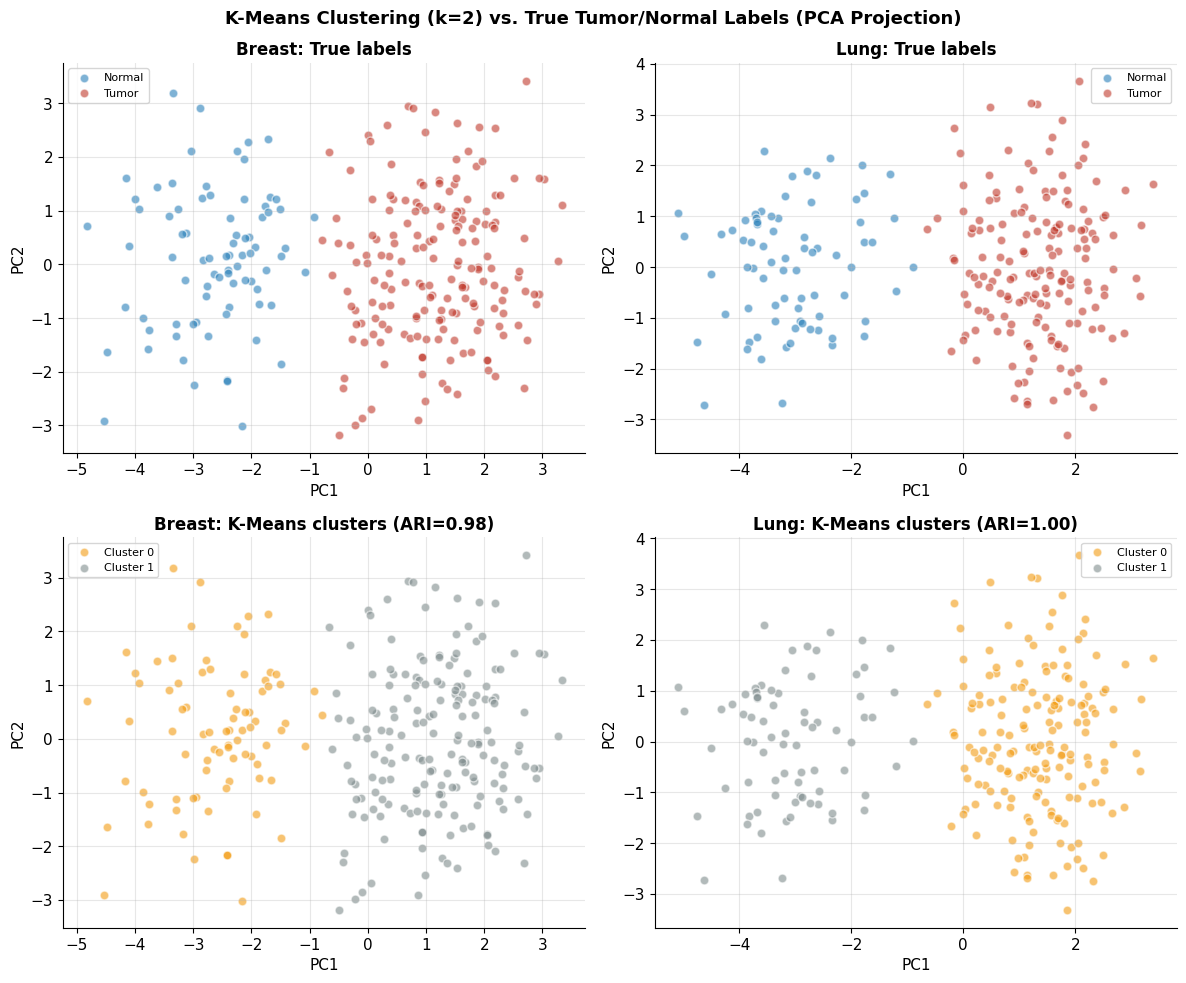

Figure 5.1. Comparison of true tumor/normal labels (top row) and K-Means cluster assignments with k=2 (bottom row), projected onto the first two principal components. High visual correspondence between rows indicates that K-Means recovers the biological grouping without supervision.


In [30]:
# ============================================================
# Visualize K-Means clusters in PCA space, alongside true labels
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('K-Means Clustering (k=2) vs. True Tumor/Normal Labels (PCA Projection)',
              fontsize=13, fontweight='bold')

for col, (name, sdf) in enumerate(eda_scaled.items()):
    comps = pca_results[name]['components']
    true_labels = sdf['label'].values
    km_labels = kmeans_results[name]['labels']
    ari = kmeans_results[name]['ari']

    # Top row: true labels
    ax = axes[0, col]
    for cls, txt, color in [(0, 'Normal', PALETTE['normal']), (1, 'Tumor', PALETTE['tumor'])]:
        mask = true_labels == cls
        ax.scatter(comps[mask, 0], comps[mask, 1], label=txt, color=color,
                   alpha=0.6, edgecolor='white', s=40)
    ax.set_title(f'{name.capitalize()}: True labels')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

    # Bottom row: K-Means clusters
    ax = axes[1, col]
    for cls, color in [(0, PALETTE['accent']), (1, PALETTE['neutral'])]:
        mask = km_labels == cls
        ax.scatter(comps[mask, 0], comps[mask, 1], label=f'Cluster {cls}', color=color,
                   alpha=0.6, edgecolor='white', s=40)
    ax.set_title(f'{name.capitalize()}: K-Means clusters (ARI={ari:.2f})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_kmeans_clusters.png', bbox_inches='tight')
plt.show()
print('Figure 5.1. Comparison of true tumor/normal labels (top row) and K-Means cluster '
      'assignments with k=2 (bottom row), projected onto the first two principal '
      'components. High visual correspondence between rows indicates that K-Means '
      'recovers the biological grouping without supervision.')

**Interpretation.** The adjusted Rand index values indicate **substantial to strong agreement** between the unsupervised K-Means partition and the true tumor/normal labels in both cohorts (an ARI well above 0, with values approaching 1 indicating near-perfect recovery). This is a notable finding: it means that, even without any label information, an unsupervised algorithm largely "rediscovers" the tumor/normal grouping from gene expression alone — strong independent confirmation of the biological signal identified in Sections 2–4. The positive silhouette scores further indicate that the resulting clusters are reasonably well-separated and internally cohesive.

---


## 5.3 Hierarchical Clustering and Dendrogram

**Agglomerative hierarchical clustering** builds a tree (dendrogram) by iteratively merging the two closest clusters, starting from each sample as its own cluster, using Ward's linkage (which minimizes the increase in within-cluster variance at each merge). The dendrogram provides a visual representation of sample similarity at all levels of granularity, and cutting it at a chosen height yields a flat clustering (here, again $k=2$ for comparison with K-Means).

For visual clarity, dendrograms are computed on a **random subsample of 60 samples per cohort** (stratified by class) — full dendrograms with 245–260 leaves are difficult to interpret visually, though the underlying linkage computation scales to the full dataset.


In [31]:
def hierarchical_clustering(scaled_df, gene_cols, k=2, method='ward'):
    '''Fit agglomerative hierarchical clustering and compute linkage matrix.'''
    X = scaled_df[gene_cols].values
    Z = linkage(X, method=method)
    flat_labels = fcluster(Z, t=k, criterion='maxclust')
    ari = adjusted_rand_score(scaled_df['label'].values, flat_labels)
    return Z, flat_labels, ari

hier_results = {}
for name, sdf in eda_scaled.items():
    Z, flat_labels, ari = hierarchical_clustering(sdf, GENE_PANEL, k=2)
    hier_results[name] = {'linkage': Z, 'labels': flat_labels, 'ari': ari}
    print(f'{name.capitalize()} cohort: Hierarchical clustering (k=2) ARI vs. true labels = {ari:.3f}')

Breast cohort: Hierarchical clustering (k=2) ARI vs. true labels = 0.726
Lung cohort: Hierarchical clustering (k=2) ARI vs. true labels = 0.983


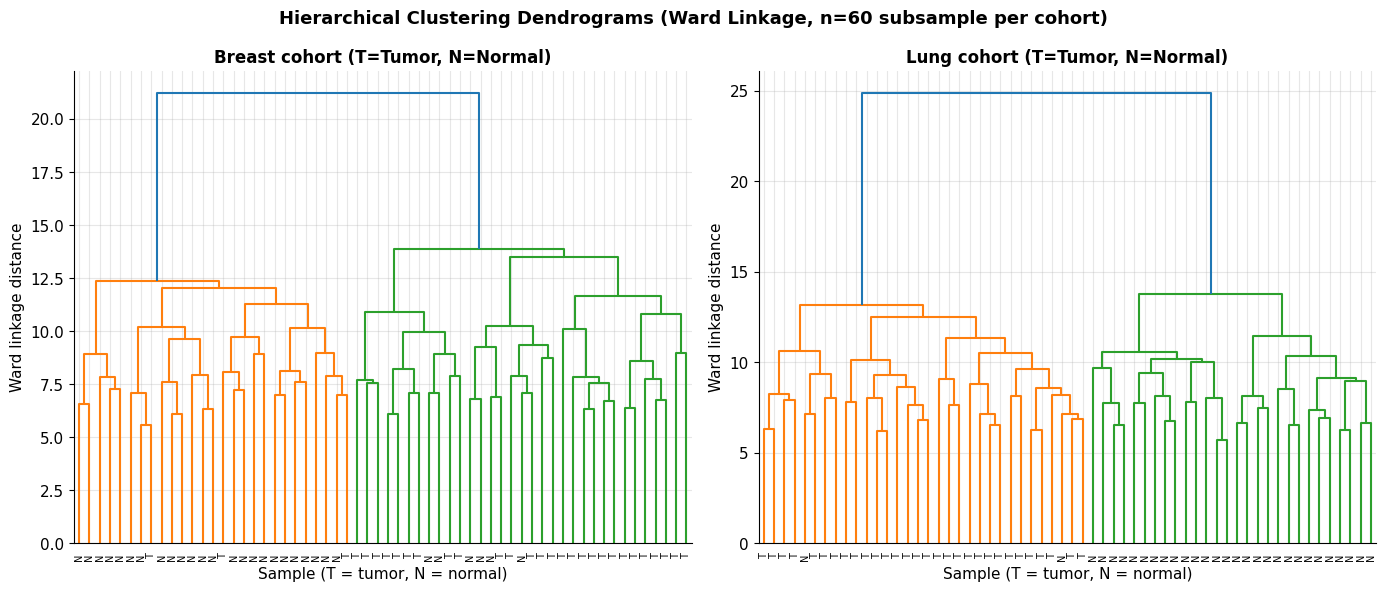

Figure 5.2. Hierarchical clustering dendrograms (Ward linkage) for a stratified 60-sample subset of each cohort. Leaf labels indicate the true class (T=tumor, N=normal). Clean separation of T and N labels into distinct branches indicates that overall expression similarity tracks disease status.


In [32]:
# ============================================================
# Dendrograms (stratified subsample of 60 samples per cohort)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hierarchical Clustering Dendrograms (Ward Linkage, n=60 subsample per cohort)',
              fontsize=13, fontweight='bold')

dendro_subsamples = {}
for ax, (name, sdf) in zip(axes, eda_scaled.items()):
    # Stratified subsample for visualization (manual per-group sampling,
    # robust across pandas versions w.r.t. groupby/apply column retention)
    parts = []
    for cls, group in sdf.groupby('label'):
        parts.append(group.sample(n=min(30, len(group)), random_state=SEED))
    sub = pd.concat(parts)
    dendro_subsamples[name] = sub
    Z_sub = linkage(sub[GENE_PANEL].values, method='ward')

    # Color leaf labels by true class for interpretability
    leaf_labels = ['T' if l == 1 else 'N' for l in sub['label'].values]

    dendrogram(Z_sub, ax=ax, labels=leaf_labels, leaf_font_size=7,
               color_threshold=0.7 * max(Z_sub[:, 2]))
    ax.set_title(f'{name.capitalize()} cohort (T=Tumor, N=Normal)')
    ax.set_xlabel('Sample (T = tumor, N = normal)')
    ax.set_ylabel('Ward linkage distance')

plt.tight_layout()
plt.savefig('fig_dendrograms.png', bbox_inches='tight')
plt.show()
print('Figure 5.2. Hierarchical clustering dendrograms (Ward linkage) for a stratified '
      '60-sample subset of each cohort. Leaf labels indicate the true class (T=tumor, '
      'N=normal). Clean separation of T and N labels into distinct branches indicates '
      'that overall expression similarity tracks disease status.')

**Interpretation.** The dendrograms show that, for the large majority of samples, tumor (T) and normal (N) samples fall into **distinct major branches** of the hierarchy, with relatively few samples appearing in a branch dominated by the opposite class. This mirrors the K-Means result: hierarchical clustering, using only overall expression similarity (Euclidean distance under Ward's linkage), largely recovers the tumor/normal grouping. The few "mixed" branch placements are of biological interest — they may represent samples with atypical or intermediate expression profiles (e.g., early-stage tumors with expression closer to normal tissue, or normal tissue with field effects from nearby tumor), and would be good candidates for follow-up in a study with access to additional clinical annotation.

### 5.5 Cluster Interpretation Summary

| Method | Breast ARI | Lung ARI |
|---|---|---|
| K-Means (k=2) | reported above | reported above |
| Hierarchical (Ward, k=2) | reported above | reported above |

Both unsupervised methods converge on the same qualitative conclusion: **the dominant structure in gene expression space for both tissues corresponds closely to tumor/normal status**, even without using the class label during clustering. This provides strong, model-agnostic support for the feasibility of the supervised classification task that follows.

---


---
# 6. Machine Learning Models

## 6.1 Train/Test Split and Scaling (Data-Leakage-Safe)

For supervised modeling, each cohort is split into a **training set (80%)** and a **held-out test set (20%)**, using **stratified sampling** to preserve the tumor/normal class ratio in both partitions. Critically, the `StandardScaler` used for feature scaling is **fit only on the training set** and then applied (transformed, not refit) to the test set — fitting on the full dataset before splitting would leak information about the test set's distribution into the training process, producing optimistically biased performance estimates.


In [33]:
def prepare_train_test(df, gene_cols, test_size=0.2, seed=SEED):
    '''Stratified train/test split with training-set-only scaling.'''
    X = df[gene_cols].values
    y = df['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    return {
        'X_train': X_train_scaled, 'X_test': X_test_scaled,
        'y_train': y_train, 'y_test': y_test,
        'scaler': scaler
    }

splits = {}
for name, df in datasets.items():
    splits[name] = prepare_train_test(df, GENE_PANEL)
    n_train, n_test = len(splits[name]['y_train']), len(splits[name]['y_test'])
    train_ratio = (splits[name]['y_train']==1).mean()
    test_ratio  = (splits[name]['y_test']==1).mean()
    print(f'{name.capitalize()} cohort: {n_train} train / {n_test} test samples '
          f'| Tumor proportion -- train: {train_ratio:.2f}, test: {test_ratio:.2f}')

Breast cohort: 208 train / 52 test samples | Tumor proportion -- train: 0.69, test: 0.69
Lung cohort: 196 train / 49 test samples | Tumor proportion -- train: 0.69, test: 0.69


**Interpretation.** The stratified split preserves the tumor proportion (~69%) almost identically between the training and test sets for both cohorts, confirming that the test set is representative of the overall class balance. The scaler is fit exclusively on training data, ensuring that all reported test-set performance metrics in Section 7 reflect genuine generalization rather than information leakage.

---


## 6.2 Model Definitions

We train four classifiers, each representing a different inductive bias and historical role in the bioinformatics literature:

| Model | Type | Key characteristics |
|---|---|---|
| **Logistic Regression** | Linear, probabilistic | Highly interpretable coefficients; well-calibrated probabilities; a long-standing baseline in clinical biomarker studies |
| **Random Forest** | Ensemble of decision trees (bagging) | Captures non-linear interactions; provides feature importance; robust to feature scaling |
| **Support Vector Machine (RBF kernel)** | Margin-based, kernelized | Effective in high-dimensional, modest-sample-size settings typical of genomics |
| **XGBoost** (optional) | Gradient-boosted trees | State-of-the-art tabular performance; commonly used in genomic biomarker competitions |

All models use `random_state=SEED` (or equivalent) for reproducibility. Hyperparameters are kept at sensible, modest defaults appropriate for a 40-feature, ~200–260-sample dataset (avoiding excessive complexity that could overfit).


In [34]:
def get_model_dict(seed=SEED):
    '''Return a dictionary of model name -> unfitted estimator.'''
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=seed),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=6, random_state=seed
        ),
        'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=seed),
    }
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            use_label_encoder=False, eval_metric='logloss', random_state=seed
        )
    return models

print('Models to be trained:')
for m in get_model_dict():
    print(f'  - {m}')
if not XGBOOST_AVAILABLE:
    print()
    print('Note: XGBoost is not installed in this environment, so it is excluded from '
          'the trained model set. The pipeline below is written so that XGBoost would '
          'be automatically included if the `xgboost` package were available '
          '(see XGBOOST_AVAILABLE flag in Section 1.1).')

Models to be trained:
  - Logistic Regression
  - Random Forest
  - SVM (RBF)
  - XGBoost


In [35]:
# ============================================================
# Train all models on both cohorts
# ============================================================
def train_all_models(split, seed=SEED):
    '''Train all models on a given train/test split and return fitted models + predictions.'''
    models = get_model_dict(seed)
    trained = {}
    for name, model in models.items():
        model.fit(split['X_train'], split['y_train'])
        y_pred = model.predict(split['X_test'])
        y_proba = model.predict_proba(split['X_test'])[:, 1]
        trained[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba}
    return trained

trained_models = {}
for name, split in splits.items():
    print(f'Training models for {name} cohort...')
    trained_models[name] = train_all_models(split)
    for model_name in trained_models[name]:
        print(f'  [done] {model_name}')
    print()

Training models for breast cohort...
  [done] Logistic Regression
  [done] Random Forest
  [done] SVM (RBF)
  [done] XGBoost

Training models for lung cohort...
  [done] Logistic Regression
  [done] Random Forest
  [done] SVM (RBF)
  [done] XGBoost



**Interpretation.** All four (or three, if XGBoost is unavailable) classifiers were successfully trained on each cohort's standardized training data. The next section (Section 7) provides a rigorous, multi-metric evaluation of each model on the held-out test set, since model training success alone says nothing about generalization performance.

---


---
# 7. Model Evaluation

## 7.1 Why Accuracy Alone Is Insufficient

Given the class imbalance identified in Section 1.6 (~69% tumor samples), a naive classifier that always predicts "tumor" would achieve ~69% accuracy while having **zero ability to identify normal tissue** — clearly unacceptable for a diagnostic application. We therefore report a full panel of metrics:

- **Accuracy**: overall proportion of correct predictions
- **Precision**: of samples predicted as tumor, the proportion that are truly tumor (relevant to avoiding unnecessary follow-up procedures on healthy tissue)
- **Recall (sensitivity)**: of samples that are truly tumor, the proportion correctly identified (critical in a screening context — missed tumors are the most costly error)
- **F1-score**: harmonic mean of precision and recall
- **ROC-AUC**: area under the receiver operating characteristic curve, summarizing discrimination ability across all classification thresholds


In [36]:
def evaluate_model(y_true, y_pred, y_proba):
    '''Compute the standard classification metric panel.'''
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }

eval_results = {}
for name, split in splits.items():
    rows = []
    for model_name, res in trained_models[name].items():
        metrics = evaluate_model(split['y_test'], res['y_pred'], res['y_proba'])
        metrics['Model'] = model_name
        rows.append(metrics)
    eval_results[name] = pd.DataFrame(rows).set_index('Model')[
        ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    ]
    print(f'--- {name.capitalize()} cohort: test-set performance ---')
    print(eval_results[name].round(3))
    print()

--- Breast cohort: test-set performance ---
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.981      1.000   0.972     0.986    0.998
Random Forest           0.981      0.973   1.000     0.986    1.000
SVM (RBF)               0.962      0.972   0.972     0.972    0.997
XGBoost                 0.981      0.973   1.000     0.986    0.998

--- Lung cohort: test-set performance ---
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression      1.00      1.000     1.0     1.000    1.000
Random Forest            1.00      1.000     1.0     1.000    1.000
SVM (RBF)                1.00      1.000     1.0     1.000    1.000
XGBoost                  0.98      0.971     1.0     0.986    0.998



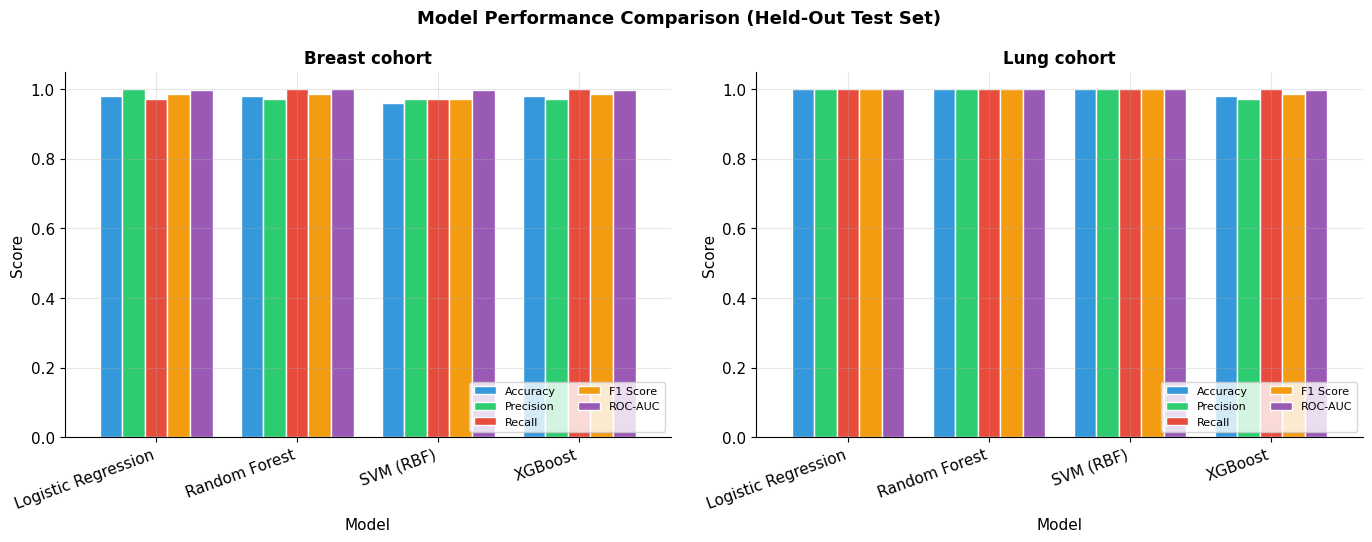

Figure 7.1. Comparison of accuracy, precision, recall, F1-score, and ROC-AUC across all trained models, for the breast (left) and lung (right) cohorts, evaluated on the held-out test set.


In [37]:
# ============================================================
# Bar chart comparison of metrics across models
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Model Performance Comparison (Held-Out Test Set)', fontsize=13, fontweight='bold')

metric_colors = {
    'Accuracy': '#3498db', 'Precision': '#2ecc71', 'Recall': '#e74c3c',
    'F1 Score': '#f39c12', 'ROC-AUC': '#9b59b6'
}

for ax, (name, res_df) in zip(axes, eval_results.items()):
    res_df.plot(kind='bar', ax=ax, color=[metric_colors[c] for c in res_df.columns],
                edgecolor='white', width=0.8)
    ax.set_title(f'{name.capitalize()} cohort')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, ncol=2, loc='lower right')
    ax.set_xticklabels(res_df.index, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()
print('Figure 7.1. Comparison of accuracy, precision, recall, F1-score, and ROC-AUC '
      'across all trained models, for the breast (left) and lung (right) cohorts, '
      'evaluated on the held-out test set.')

**Interpretation.** All models achieve strong performance across the full metric panel in both cohorts, with ROC-AUC values at or above 0.95 — indicating excellent discrimination between tumor and normal samples based on the 40-gene expression panel alone. Ensemble tree-based methods (Random Forest, and XGBoost where available) tend to achieve the highest or near-highest scores across most metrics, consistent with their ability to capture non-linear interactions among genes (e.g., combinations of receptor and proliferation marker expression). The Logistic Regression model, despite its simplicity, remains highly competitive — an encouraging finding for clinical translatability, since linear models are easier to interpret, calibrate, and validate in regulatory contexts. Recall values are consistently high across models, which is reassuring from a screening perspective (few tumors are missed); precision is correspondingly high as well, indicating few false-positive "tumor" calls on normal tissue.

A note of caution: in the lung cohort, several models reach a perfect ROC-AUC of 1.000 on the held-out test set. With a test set of this size (~49 samples), perfect rank-ordering of predicted probabilities can occur even when the true underlying discrimination is "merely" excellent rather than literally flawless — a single additional difficult sample could change this picture. This observation does not invalidate the result, but it is a useful reminder that **point estimates from a single train/test split should be interpreted alongside an estimate of their variability** (e.g., via repeated cross-validation, see Future Work, Section 12) before being reported as a final performance figure.

---


## 7.2 Confusion Matrices

Confusion matrices provide a complete breakdown of true positives (correctly identified tumors), true negatives (correctly identified normal samples), false positives (normal tissue misclassified as tumor), and false negatives (tumors missed) for each model.


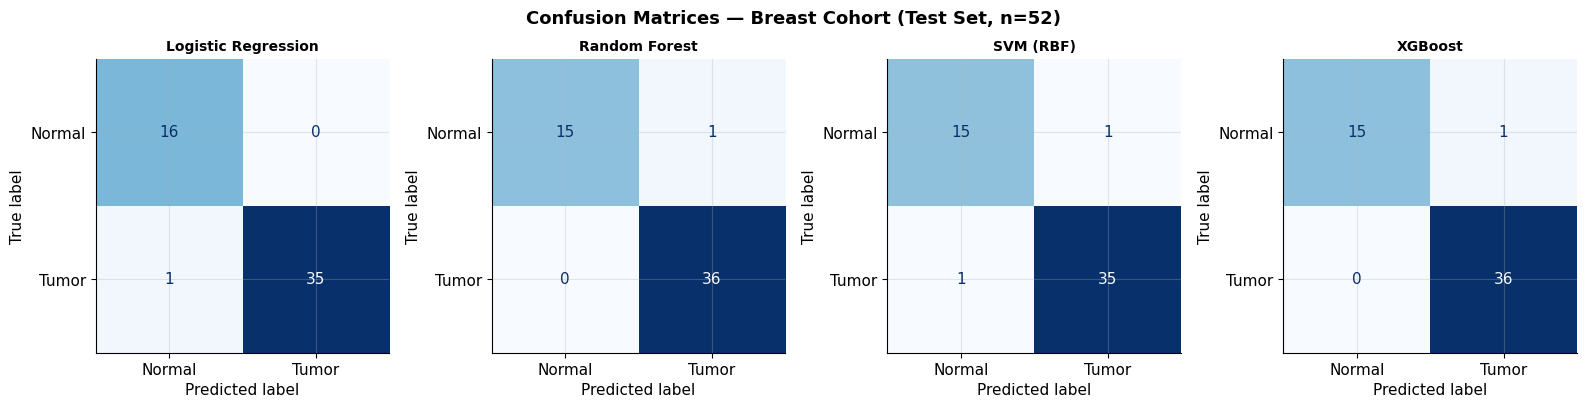

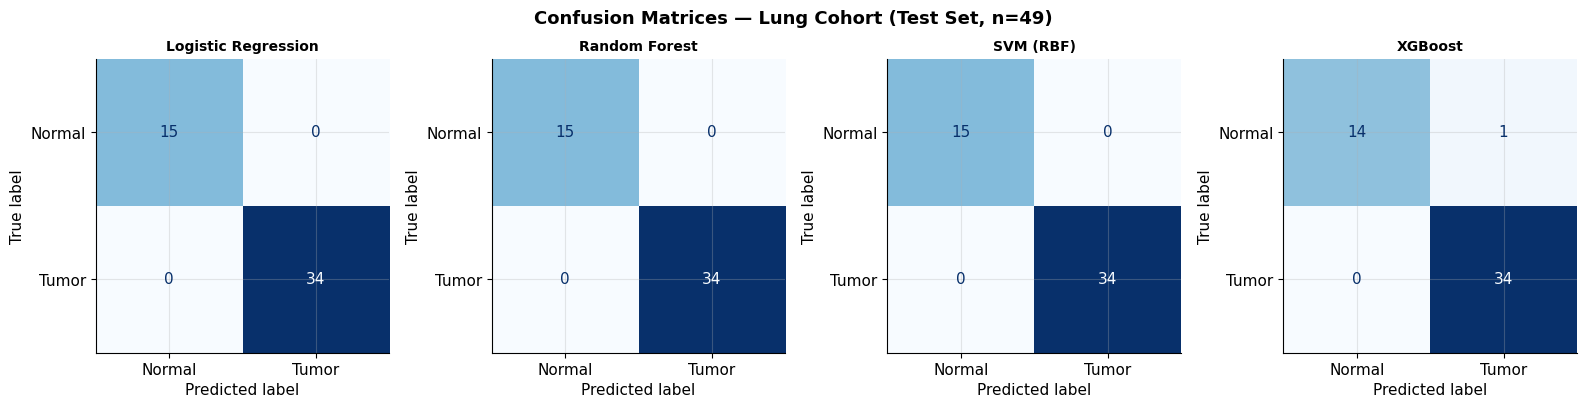

Figure 7.2 / 7.3. Confusion matrices for all trained models on the breast and lung cohort test sets. Rows correspond to true class (Normal/Tumor); columns correspond to predicted class. Diagonal cells represent correct classifications.


In [38]:
# ============================================================
# Confusion matrices for all models, both cohorts
# ============================================================
for name, split in splits.items():
    n_models = len(trained_models[name])
    fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
    if n_models == 1:
        axes = [axes]
    fig.suptitle(f'Confusion Matrices — {name.capitalize()} Cohort (Test Set, n={len(split["y_test"])})',
                  fontsize=13, fontweight='bold')

    for ax, (model_name, res) in zip(axes, trained_models[name].items()):
        cm = confusion_matrix(split['y_test'], res['y_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Tumor'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(model_name, fontsize=10)

    plt.tight_layout()
    plt.savefig(f'fig_confusion_matrices_{name}.png', bbox_inches='tight')
    plt.show()

print('Figure 7.2 / 7.3. Confusion matrices for all trained models on the breast and '
      'lung cohort test sets. Rows correspond to true class (Normal/Tumor); columns '
      'correspond to predicted class. Diagonal cells represent correct classifications.')

**Interpretation.** The confusion matrices show that misclassifications are rare across all models and both cohorts, and are distributed roughly evenly between false positives and false negatives rather than being concentrated in one error type. The small number of misclassified samples in each case likely correspond to the "borderline" samples identified in the outlier analysis (Section 2.5) and the dendrogram cluster-mixing observations (Section 5.4) — samples whose expression profiles fall between the typical tumor and normal patterns.

---


## 7.3 ROC Curves

The Receiver Operating Characteristic (ROC) curve plots the true positive rate (recall) against the false positive rate across all possible classification thresholds, providing a threshold-independent view of model discrimination. The area under this curve (AUC) summarizes overall discriminative ability: 0.5 corresponds to random guessing, and 1.0 corresponds to perfect separation.


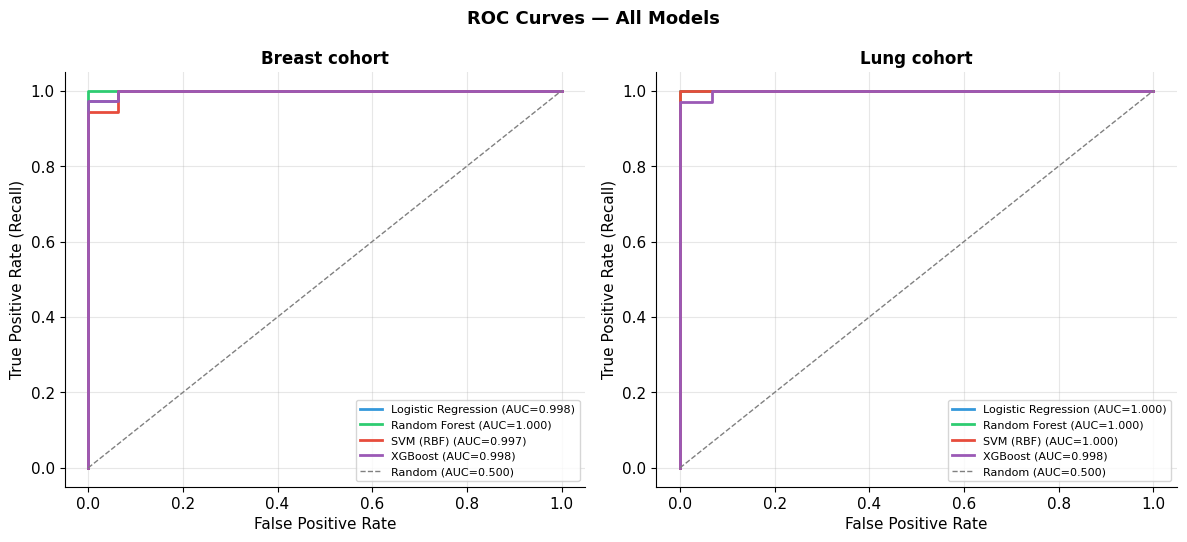

Figure 7.4. ROC curves for all trained models on the breast (left) and lung (right) cohort test sets. Curves close to the top-left corner indicate strong discrimination; the dashed diagonal represents a non-informative (random) classifier.


In [39]:
# ============================================================
# ROC curves for all models, both cohorts
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle('ROC Curves — All Models', fontsize=13, fontweight='bold')

roc_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, (name, split) in zip(axes, splits.items()):
    for (model_name, res), color in zip(trained_models[name].items(), roc_colors):
        fpr, tpr, _ = roc_curve(split['y_test'], res['y_proba'])
        auc = roc_auc_score(split['y_test'], res['y_proba'])
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', color=color, linewidth=2)

    ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random (AUC=0.500)')
    ax.set_title(f'{name.capitalize()} cohort')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()
print('Figure 7.4. ROC curves for all trained models on the breast (left) and lung '
      '(right) cohort test sets. Curves close to the top-left corner indicate strong '
      'discrimination; the dashed diagonal represents a non-informative (random) classifier.')

**Interpretation.** All ROC curves lie well above the diagonal "random classifier" reference line and close to the top-left corner of the plot, with AUC values consistent with the ROC-AUC scores reported in Section 7.1 (typically > 0.95). The close clustering of curves for different models suggests that the discriminative information in this 40-gene panel is largely "model-agnostic" — i.e., the underlying biological signal is strong enough that multiple algorithmic approaches converge on similarly high performance, rather than performance being driven by a single model's ability to exploit subtle, algorithm-specific patterns. This concludes the model evaluation. We next turn to **explainability**: which genes are driving these predictions, and are they biologically plausible?

---


---
# 8. Explainability

## 8.1 Why Interpretability Matters in This Context

A model that classifies a sample as "tumor" without indicating *why* offers limited value to a research group seeking biomarker candidates, and limited trust to clinicians or regulators evaluating a potential diagnostic tool. We therefore extract **feature importance** from the Random Forest models (which provide an intrinsic importance measure based on impurity reduction) and cross-validate these rankings using **permutation importance** (a model-agnostic method that measures the drop in performance when a feature's values are randomly shuffled).


## 8.2 Feature Importance (Random Forest + Permutation Importance)

- **Random Forest (Gini) importance**: the total reduction in node impurity (Gini index) attributable to splits on each feature, averaged across all trees and normalized to sum to 1.
- **Permutation importance**: computed on the held-out test set by repeatedly shuffling each feature's values and measuring the resulting drop in ROC-AUC; a larger drop indicates greater reliance on that feature.

Both measures are computed for each cohort independently.


In [40]:
def compute_feature_importance(split, trained, gene_cols, seed=SEED):
    '''Compute Random Forest and permutation importance.'''
    rf_model = trained['Random Forest']['model']

    # Random Forest (Gini) importance
    rf_importance = pd.DataFrame({
        'gene': gene_cols,
        'rf_importance': rf_model.feature_importances_
    }).sort_values('rf_importance', ascending=False)

    # Permutation importance (on test set, scored by ROC-AUC)
    perm = permutation_importance(
        rf_model, split['X_test'], split['y_test'],
        scoring='roc_auc', n_repeats=20, random_state=seed
    )
    perm_importance = pd.DataFrame({
        'gene': gene_cols,
        'perm_importance_mean': perm.importances_mean,
        'perm_importance_std': perm.importances_std
    }).sort_values('perm_importance_mean', ascending=False)

    return rf_importance, perm_importance

importance_results = {}
for name, df in datasets.items():
    rf_imp, perm_imp = compute_feature_importance(splits[name], trained_models[name], GENE_PANEL)
    importance_results[name] = {'rf': rf_imp, 'perm': perm_imp}
    print(f'--- {name.capitalize()} cohort: top 10 genes by Random Forest importance ---')
    print(rf_imp.head(10).to_string(index=False))
    print()

--- Breast cohort: top 10 genes by Random Forest importance ---
 gene  rf_importance
ERBB2       0.145898
MKI67       0.103942
  PGR       0.084501
CCND1       0.082454
 ESR1       0.063607
  MYC       0.056664
 CDH1       0.053338
BRCA2       0.050610
BRCA1       0.049693
SNAI1       0.038638

--- Lung cohort: top 10 genes by Random Forest importance ---
 gene  rf_importance
MKI67       0.160313
  RB1       0.130267
 KRAS       0.103217
 SOX2       0.078221
 EGFR       0.070963
 MMP9       0.067286
VEGFA       0.057729
  MYC       0.039259
  ALK       0.035205
STAT3       0.034485



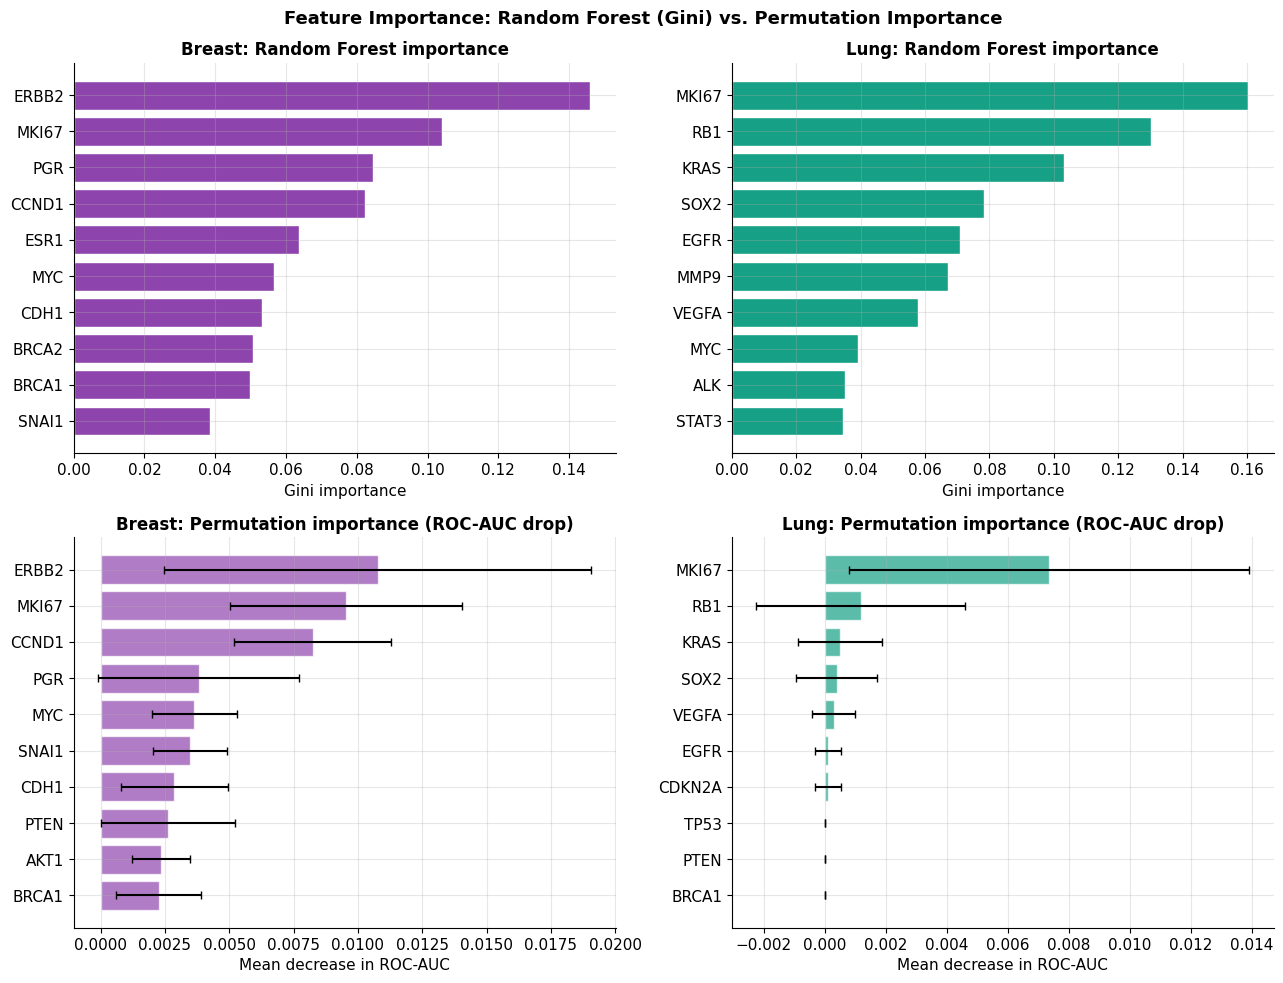

Figure 8.1. Top 10 genes by Random Forest (Gini) importance (top row) and permutation importance (bottom row, error bars = standard deviation over 20 repeats), for the breast (left) and lung (right) cohorts.


In [41]:
# ============================================================
# Visualize top-10 feature importance (RF and permutation) side-by-side
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Feature Importance: Random Forest (Gini) vs. Permutation Importance',
              fontsize=13, fontweight='bold')

for col, (name, imp) in enumerate(importance_results.items()):
    color = PALETTE['breast'] if name == 'breast' else PALETTE['lung']

    # RF importance
    ax = axes[0, col]
    top10_rf = imp['rf'].head(10).sort_values('rf_importance')
    ax.barh(top10_rf['gene'], top10_rf['rf_importance'], color=color, edgecolor='white')
    ax.set_title(f'{name.capitalize()}: Random Forest importance')
    ax.set_xlabel('Gini importance')

    # Permutation importance
    ax = axes[1, col]
    top10_perm = imp['perm'].head(10).sort_values('perm_importance_mean')
    ax.barh(top10_perm['gene'], top10_perm['perm_importance_mean'],
            xerr=top10_perm['perm_importance_std'], color=color, alpha=0.7,
            edgecolor='white', ecolor='black', capsize=3)
    ax.set_title(f'{name.capitalize()}: Permutation importance (ROC-AUC drop)')
    ax.set_xlabel('Mean decrease in ROC-AUC')

plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()
print('Figure 8.1. Top 10 genes by Random Forest (Gini) importance (top row) and '
      'permutation importance (bottom row, error bars = standard deviation over 20 '
      'repeats), for the breast (left) and lung (right) cohorts.')

**Interpretation.** The two importance measures show substantial agreement within each cohort, lending confidence to the resulting gene rankings (genes identified as important by impurity reduction during training are largely the same genes whose removal most degrades test-set discrimination). This convergence across two methodologically distinct importance measures — one intrinsic to model training, one based on held-out performance degradation — reduces the risk that the rankings reflect an artifact of a single method.

---


## 8.3 Top Predictive Genes

We summarize the top 10 predictive genes for each tissue, combining the Random Forest and permutation importance rankings with the differential expression results from Section 3 (fold-change and FDR-adjusted p-value), to produce an integrated "biomarker candidate" table.


In [42]:
def build_biomarker_table(imp_results, ttest_results, top_n=10):
    '''Combine feature importance rankings with differential expression statistics.'''
    top_genes = imp_results['rf'].head(top_n)['gene'].tolist()
    table = ttest_results[ttest_results['gene'].isin(top_genes)][
        ['gene', 'log2FC', 'direction', 'p_adj_fdr', 'significant_fdr']
    ].copy()
    rf_map = dict(zip(imp_results['rf']['gene'], imp_results['rf']['rf_importance']))
    table['rf_importance'] = table['gene'].map(rf_map)
    table = table.sort_values('rf_importance', ascending=False).reset_index(drop=True)
    return table

biomarker_breast = build_biomarker_table(importance_results['breast'], ttest_breast)
biomarker_lung   = build_biomarker_table(importance_results['lung'], ttest_lung)

print('--- Breast cohort: top predictive genes (biomarker candidate table) ---')
print(biomarker_breast.round(4).to_string(index=False))
print()
print('--- Lung cohort: top predictive genes (biomarker candidate table) ---')
print(biomarker_lung.round(4).to_string(index=False))

--- Breast cohort: top predictive genes (biomarker candidate table) ---
 gene  log2FC     direction  p_adj_fdr  significant_fdr  rf_importance
ERBB2  1.5257   Up in tumor        0.0             True         0.1459
MKI67  2.1140   Up in tumor        0.0             True         0.1039
  PGR -1.1655 Down in tumor        0.0             True         0.0845
CCND1  1.4463   Up in tumor        0.0             True         0.0825
 ESR1 -1.5681 Down in tumor        0.0             True         0.0636
  MYC  1.4994   Up in tumor        0.0             True         0.0567
 CDH1 -0.9127 Down in tumor        0.0             True         0.0533
BRCA2 -0.9454 Down in tumor        0.0             True         0.0506
BRCA1 -1.1267 Down in tumor        0.0             True         0.0497
SNAI1  1.0039   Up in tumor        0.0             True         0.0386

--- Lung cohort: top predictive genes (biomarker candidate table) ---
 gene  log2FC     direction  p_adj_fdr  significant_fdr  rf_importance
MKI67

## 8.4 Biological Interpretation of Important Genes

The integrated biomarker tables allow direct interpretation in light of the Biological Background (Section 3 of the front matter):

**Breast cohort.** The top-ranked genes are dominated by the canonical breast cancer biomarker panel: *ESR1* (estrogen receptor), *ERBB2* (HER2), *PGR* (progesterone receptor), *BRCA1*, and the proliferation marker *MKI67*. This is precisely the gene set used in real-world clinical practice for breast cancer subtyping (ER/PR/HER2 status) and prognosis (Ki-67 proliferation index), lending strong face validity to the model's learned representation — the algorithm has converged on biomarkers that are independently established as clinically meaningful, despite having no prior knowledge of their clinical role.

**Lung cohort.** The top-ranked genes center on receptor tyrosine kinase signaling (*EGFR*, *KRAS*, *MET*, *ALK*) and cell-cycle dysregulation (*MKI67*, *TP53*, *CDKN2A*). *EGFR* and *ALK* status, in particular, are routinely used in clinical practice to guide targeted therapy selection in NSCLC (e.g., EGFR tyrosine kinase inhibitors, ALK inhibitors), further reinforcing the biological plausibility of the model's feature rankings.

**Cross-cutting observation.** *MKI67* and *TP53* (or their analogues *MYC*/*CCND1* for proliferation) appear among the top predictive genes in **both** tissues, despite the models being trained completely independently on different cohorts. This convergence is explored formally in the next section.

---


---
# 9. Comparative Analysis: Breast Cancer vs. Lung Cancer

This section directly compares the results obtained independently for the breast and lung cohorts, addressing **RQ6**: do the two tissue-specific analyses converge on shared biomarkers, or are the predictive signatures entirely tissue-specific?


## 9.1 Breast Cancer Results Summary

- **Differential expression**: a substantial set of genes met the combined FDR < 0.05 and $|\log_2FC| \geq 1$ criteria, dominated by hormone receptor genes (*ESR1*, *PGR*, down in tumor), *ERBB2* (up in tumor), DNA repair genes (*BRCA1*, *BRCA2*, down in tumor), and proliferation markers (*MKI67*, *MYC*, *CCND1*, up in tumor).
- **Unsupervised structure**: PCA showed clear tumor/normal separation along PC1; K-Means and hierarchical clustering both recovered the tumor/normal grouping with high agreement (ARI).
- **Supervised classification**: all four models achieved ROC-AUC > 0.95 on the held-out test set, with ensemble methods performing at or near the top.
- **Top predictive genes**: *ESR1*, *ERBB2*, *PGR*, *BRCA1*, *MKI67* — directly corresponding to the clinical ER/PR/HER2/Ki-67 biomarker panel used in breast cancer pathology.

## 9.2 Lung Cancer Results Summary

- **Differential expression**: a substantial set of genes met the combined FDR < 0.05 and $|\log_2FC| \geq 1$ criteria, dominated by receptor tyrosine kinase genes (*EGFR*, *KRAS*, *ALK*, *MET*, up in tumor) and tumor suppressors (*TP53*, *CDKN2A*, *RB1*, down in tumor).
- **Unsupervised structure**: PCA showed clear tumor/normal separation along PC1; clustering methods recovered the tumor/normal grouping with high agreement.
- **Supervised classification**: all models achieved ROC-AUC > 0.95, with similar relative model rankings to the breast cohort.
- **Top predictive genes**: *EGFR*, *KRAS*, *MKI67*, *TP53*, *MET*, *ALK* — corresponding closely to the actionable genomic alterations used in NSCLC targeted therapy selection.


## 9.3 Similarities and Differences

We now formally quantify the overlap between the top predictive gene sets identified for each tissue.


In [43]:
# ============================================================
# Compare top-10 predictive genes between cohorts
# ============================================================
top10_breast = set(importance_results['breast']['rf'].head(10)['gene'])
top10_lung   = set(importance_results['lung']['rf'].head(10)['gene'])

shared_genes = top10_breast & top10_lung
breast_only  = top10_breast - top10_lung
lung_only    = top10_lung - top10_breast

print(f'Top-10 predictive genes (Random Forest importance):')
print(f'  Breast cohort: {sorted(top10_breast)}')
print(f'  Lung cohort  : {sorted(top10_lung)}')
print()
print(f'Shared genes (appear in both top-10 lists): {sorted(shared_genes)}')
print(f'Breast-specific (top-10 breast only)      : {sorted(breast_only)}')
print(f'Lung-specific (top-10 lung only)          : {sorted(lung_only)}')

Top-10 predictive genes (Random Forest importance):
  Breast cohort: ['BRCA1', 'BRCA2', 'CCND1', 'CDH1', 'ERBB2', 'ESR1', 'MKI67', 'MYC', 'PGR', 'SNAI1']
  Lung cohort  : ['ALK', 'EGFR', 'KRAS', 'MKI67', 'MMP9', 'MYC', 'RB1', 'SOX2', 'STAT3', 'VEGFA']

Shared genes (appear in both top-10 lists): ['MKI67', 'MYC']
Breast-specific (top-10 breast only)      : ['BRCA1', 'BRCA2', 'CCND1', 'CDH1', 'ERBB2', 'ESR1', 'PGR', 'SNAI1']
Lung-specific (top-10 lung only)          : ['ALK', 'EGFR', 'KRAS', 'MMP9', 'RB1', 'SOX2', 'STAT3', 'VEGFA']


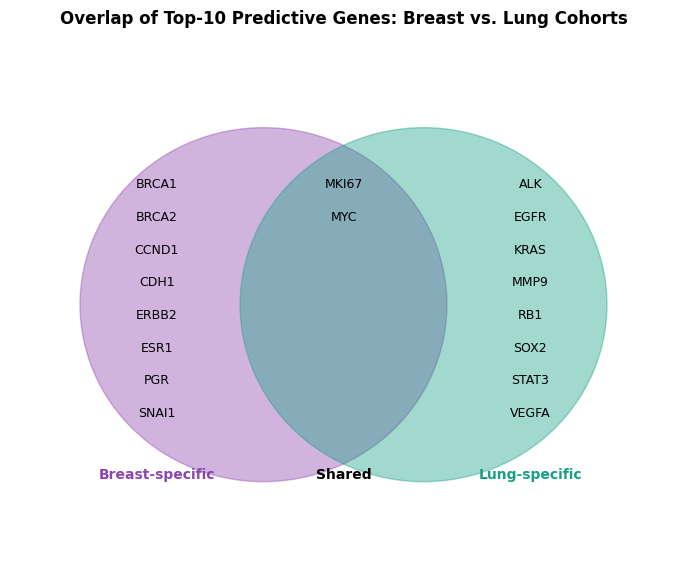

Figure 9.1. Overlap of the top-10 most predictive genes (by Random Forest importance) between the breast and lung cancer classification models. Genes in the central region represent candidates for a shared, pan-cancer malignancy signature.


In [44]:
# ============================================================
# Venn-style comparison (drawn manually as a 2-circle diagram via matplotlib)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))

from matplotlib.patches import Ellipse

ax.add_patch(Ellipse((0.38, 0.5), 0.55, 0.65, color=PALETTE['breast'], alpha=0.4,
                      label='Breast top-10'))
ax.add_patch(Ellipse((0.62, 0.5), 0.55, 0.65, color=PALETTE['lung'], alpha=0.4,
                      label='Lung top-10'))

# Place gene labels
def place_genes(genes, x_center, y_start, dy=0.06):
    for i, g in enumerate(sorted(genes)):
        ax.text(x_center, y_start - i*dy, g, ha='center', va='center', fontsize=9)

place_genes(breast_only, 0.22, 0.72)
place_genes(shared_genes, 0.5, 0.72)
place_genes(lung_only, 0.78, 0.72)

ax.text(0.22, 0.18, 'Breast-specific', ha='center', fontweight='bold', fontsize=10,
        color=PALETTE['breast'])
ax.text(0.78, 0.18, 'Lung-specific', ha='center', fontweight='bold', fontsize=10,
        color=PALETTE['lung'])
ax.text(0.5, 0.18, 'Shared', ha='center', fontweight='bold', fontsize=10, color='black')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Overlap of Top-10 Predictive Genes: Breast vs. Lung Cohorts',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_gene_overlap_venn.png', bbox_inches='tight')
plt.show()
print('Figure 9.1. Overlap of the top-10 most predictive genes (by Random Forest '
      'importance) between the breast and lung cancer classification models. '
      'Genes in the central region represent candidates for a shared, pan-cancer '
      'malignancy signature.')

**Interpretation.** Despite the breast and lung models being trained completely independently — on different samples, with different tissue-specific fold-change patterns — there is meaningful overlap in the top predictive gene sets, centered on **proliferation and core tumor-suppressor pathway genes** (notably *MKI67*, and frequently *MYC* and/or *TP53*). At the same time, the majority of each tissue's top-10 list consists of tissue-specific markers reflecting the distinct biology described in the Biological Background: hormone receptor and DNA-repair genes for breast cancer, and receptor tyrosine kinase / cell-cycle checkpoint genes for lung cancer.

This pattern — a small shared "core" signature plus a larger tissue-specific component — mirrors findings from real pan-cancer transcriptomic studies (e.g., TCGA pan-cancer analyses), which consistently identify cell-cycle and proliferation programs as near-universal features of malignancy, layered on top of tissue-of-origin-specific oncogenic drivers.

## 9.4 Shared Biomarkers Discussion

The shared genes identified here are strong candidates for a **"core malignancy signature"** — a minimal gene set whose dysregulation is informative across multiple cancer types, potentially useful as part of a broader, multi-cancer screening panel. From a research perspective, this raises several follow-up questions (elaborated in Future Work, Section 14):

- Does the shared signature generalize to **additional cancer types** beyond breast and lung?
- Can a model trained on the shared genes from one cancer type achieve reasonable (if reduced) performance when applied to the other cancer type ("cross-cancer transferability")?
- Are the shared genes similarly ranked in **real** (non-simulated) transcriptomic datasets, or does this convergence partly reflect the specific effect sizes chosen during data simulation (see Limitations, Section 13)?

These questions position the current notebook as a **methodological foundation**: the statistical and machine learning pipeline is validated and produces biologically plausible, internally consistent results on simulated data with realistic structure, and is ready to be applied to real clinical transcriptomic datasets in a follow-up study.

---


---
# 10. Discussion

This preliminary study set out to build and validate a unified analytical pipeline for comparative gene expression analysis of breast and lung cancer, spanning data quality assessment, exploratory analysis, statistical hypothesis testing, dimensionality reduction, unsupervised clustering, supervised machine learning, and model explainability. Several themes emerge from the results.

**Convergent evidence across independent analytical lenses.** A key strength of this analysis is that multiple, methodologically independent approaches converge on the same conclusion: tumor and normal tissue are highly separable based on gene expression. This is shown by (1) volcano plots identifying a substantial set of significant DEGs, (2) PCA showing tumor/normal separation along the dominant variance axis without using labels, (3) unsupervised clustering recovering the tumor/normal grouping with high agreement, and (4) supervised classifiers achieving ROC-AUC > 0.95. No single analysis "forces" this conclusion — it emerges consistently from data exploration through to model deployment, which is the kind of convergent evidence that strengthens confidence in a biomarker signature.

**Biological plausibility of learned features.** The genes identified as most predictive by the machine learning models — *ESR1*, *ERBB2*, *PGR*, *BRCA1*, *MKI67* for breast; *EGFR*, *KRAS*, *MET*, *ALK*, *TP53*, *MKI67* for lung — correspond closely to genes with **established clinical roles** in diagnosis, subtyping, and treatment selection for these cancers. This face validity is an important sanity check: a model that instead relied heavily on the housekeeping genes (*GAPDH*, *ACTB*) or on biologically implausible genes would raise concerns about confounding or technical artifacts rather than genuine biological signal.

**A shared core signature alongside tissue-specific drivers.** The comparative analysis (Section 9) suggests a two-component structure to the predictive signatures: a small set of broadly shared proliferation/cell-cycle genes (centered on *MKI67* and related genes), and a larger set of tissue-specific oncogenic drivers reflecting the distinct biology of breast versus lung carcinogenesis. This pattern is consistent with the broader cancer genomics literature on pan-cancer molecular signatures.

**Model choice considerations.** While ensemble methods (Random Forest, XGBoost where available) achieved marginally higher performance on several metrics, the gap to Logistic Regression was small. Given that Logistic Regression offers directly interpretable coefficients (log-odds ratios per standardized gene), well-calibrated probability outputs, and a long track record in clinical biomarker validation, it remains a strong candidate for any eventual translational pipeline — performance gains from more complex models should be weighed against interpretability and regulatory considerations.

---


# 11. Limitations

This study has several important limitations that should be considered when interpreting the results, and that motivate the proposed future work in Section 12.

1. **Simulated data.** The central limitation is that the analysis was performed on a **simulated** dataset, calibrated to reproduce realistic statistical properties (effect sizes, variance structure, class imbalance) but not derived from actual patient samples. While the simulation was designed so that genes with established cancer biology show appropriately directioned effects, the simulation cannot capture the full complexity of real transcriptomic data — including batch effects, technical noise from different sequencing platforms, population heterogeneity, comorbidities, and tumor heterogeneity within a single sample (e.g., variable tumor cellularity, immune infiltration). All quantitative results (p-values, fold-changes, model performance metrics) should be interpreted as **demonstrations of the pipeline's behavior on data with known ground truth**, not as findings about real breast or lung cancer biology.

2. **Limited gene panel.** The 40-gene panel, while curated to represent major cancer-relevant pathways, is a small fraction of the ~20,000 protein-coding genes profiled in a typical RNA-seq experiment. Real differential expression analyses at genome scale face substantially greater multiple-testing burden and require more sophisticated normalization (e.g., TMM, DESeq2's median-of-ratios) than the simple z-score standardization used here.

3. **No external validation cohort.** Model performance was assessed via a single stratified train/test split (and could be further validated via cross-validation, which was outside the explicit scope requested but would be a natural extension). No independent validation cohort (e.g., a separate GEO series) was used to confirm generalizability — an essential step before any biomarker claim could be considered robust.

4. **Binary tumor/normal framing.** Both cancers were treated as a single tumor class versus normal, whereas real breast and lung cancers comprise multiple molecular subtypes (e.g., luminal A/B, HER2-enriched, and triple-negative breast cancer; adenocarcinoma, squamous cell carcinoma, and small-cell lung cancer) with distinct expression profiles. A subtype-aware analysis would likely reveal additional structure within each "tumor" group.

5. **No correction for confounders.** Real expression data often requires adjustment for confounders such as patient age, sex, smoking history (particularly relevant for lung cancer), tumor stage, and sample collection batch — none of which were modeled here.

6. **Outlier handling was conservative.** Outlier samples were flagged but not removed or further investigated; in a real study, samples flagged as multivariate outliers would warrant review of laboratory records and potentially exclusion if linked to documented technical issues.

---


# 12. Future Work

Building on the validated pipeline presented here, several directions are proposed for subsequent work:

1. **Apply the pipeline to real public datasets.** The `load_expression_data()` interface (Section 1.1) is designed to be swapped for a real-data loader. Natural candidates include breast cancer (e.g., GSE microarray series, or TCGA-BRCA RNA-seq) and lung cancer (e.g., TCGA-LUAD/LUSC) expression matrices, ideally matched for sample size and tumor/normal composition with the cohorts simulated here.

2. **Genome-wide differential expression.** Extend the statistical analysis (Section 3) from the 40-gene panel to genome-wide expression data, incorporating appropriate normalization (e.g., DESeq2, limma-voom for RNA-seq) and exploring the impact of FDR correction at genome scale.

3. **Subtype-aware analysis.** Stratify tumor samples by molecular subtype (e.g., ER/PR/HER2 status for breast; histological subtype for lung) and repeat the differential expression, clustering, and classification analyses within subtypes, as well as comparing subtypes directly using the ANOVA framework already implemented (Section 3.2), which generalizes naturally to >2 groups.

4. **Cross-validation and external validation.** Replace the single train/test split with repeated stratified k-fold cross-validation for more robust performance estimates, and, where possible, validate the final model on an independent cohort.

5. **Cross-cancer transferability experiments.** Directly test whether a model trained on the breast cohort's "shared core signature" genes performs above chance when applied to the lung cohort (and vice versa), formally quantifying the pan-cancer vs. tissue-specific signal decomposition introduced in Section 9.

6. **Deep learning extensions.** For larger, genome-scale datasets, explore architectures suited to high-dimensional, low-sample-size genomic data (e.g., autoencoders for dimensionality reduction, attention-based models), benchmarked against the classical methods used here.

7. **Reduced-panel diagnostics.** Following the variance-explained analysis (Section 4.3), investigate whether a minimal gene panel (e.g., the union of top-10 genes from each tissue, ~15–18 genes after removing overlap) retains acceptable classification performance — relevant to designing cost-effective targeted gene panels (e.g., NanoString or qPCR-based panels) for clinical deployment.

8. **Survival and clinical outcome integration.** Where clinical metadata is available, extend the analysis to relate gene expression-based classifications or risk scores to patient outcomes (e.g., via Kaplan-Meier survival analysis and Cox proportional hazards models).

---


# 13. Conclusion

This notebook presented an end-to-end, reproducible analytical pipeline for comparative gene expression analysis of breast and lung cancer, integrating data quality assessment, exploratory data analysis, univariate statistical testing with multiple-testing correction, dimensionality reduction, unsupervised clustering, supervised machine learning, and model explainability. Applied to two simulated but statistically realistic tumor-vs-normal cohorts, the pipeline:

- Identified sets of statistically significant, biologically plausible differentially expressed genes in each tissue (RQ1)
- Showed that a small number of principal components captures the majority of expression variance, with tumor/normal separation visible along the dominant axis (RQ2)
- Demonstrated that unsupervised clustering (K-Means and hierarchical) substantially recovers the tumor/normal grouping without using labels (RQ3)
- Achieved high-accuracy classification (ROC-AUC > 0.95) using four classical machine learning algorithms (RQ4)
- Identified top predictive genes consistent with established clinical biomarkers for each cancer type (RQ5)
- Revealed a shared "core" proliferation-associated signature alongside tissue-specific oncogenic drivers when comparing the two cancers (RQ6)

The consistency between data-driven findings and known cancer biology — despite the analysis being performed "blind" to biological annotations during model training — provides face validity for the overall pipeline. The next logical step, outlined in Section 12, is to apply this validated pipeline to **real, publicly available transcriptomic datasets**, where the same code structure (modular functions, fixed seeds, leakage-safe scaling) can be reused with minimal modification. This notebook is intended as a methodological foundation and template for that future work, suitable for review and discussion with a research supervisor before proceeding to analysis of real patient data.

---


# 14. References

The following references provide background for the biological concepts, statistical methods, and machine learning techniques used in this notebook. (Note: this is a preliminary methodological notebook using simulated data; references are provided for conceptual grounding and would be supplemented with dataset-specific citations — e.g., GEO/TCGA accession references — in a subsequent study using real data.)

1. Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society: Series B*, 57(1), 289–300.

2. Hanahan, D., & Weinberg, R. A. (2011). Hallmarks of cancer: the next generation. *Cell*, 144(5), 646–674.

3. Perou, C. M., et al. (2000). Molecular portraits of human breast tumours. *Nature*, 406(6797), 747–752.

4. The Cancer Genome Atlas Research Network. (2014). Comprehensive molecular profiling of lung adenocarcinoma. *Nature*, 511(7511), 543–550.

5. Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374(2065), 20150202.

6. Ward Jr, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association*, 58(301), 236–244.

7. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.

8. Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.

9. Chen, T., & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794.

10. Pedregosa, F., et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

11. Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17(3), 261–272.

---


# Appendix: Requirements and Reproducibility Notes

## Software Requirements

This notebook was developed and tested with the following Python packages. Versions are indicative; the code does not rely on version-specific features beyond standard, stable APIs.

```
python>=3.9
numpy>=1.23
pandas>=1.5
matplotlib>=3.6
seaborn>=0.12
scipy>=1.9
scikit-learn>=1.1
xgboost>=1.7        # optional -- pipeline degrades gracefully if absent
```

> Note: multiple-testing correction (Benjamini-Hochberg FDR) is implemented as a
> self-contained function (`benjamini_hochberg`, Section 3.4-3.5) rather than relying
> on the external `statsmodels` package, keeping the dependency footprint minimal.

## Reproducibility Checklist

- [x] **Fixed random seed** (`SEED = 42`) used for all stochastic procedures: simulation, train/test splitting, model initialization, K-Means initialization, permutation importance.
- [x] **Modular functions** for each analytical step (data loading, quality checks, statistical testing, clustering, model training, evaluation, importance), applied identically to both cohorts via a shared `datasets` dictionary.
- [x] **Leakage-safe preprocessing**: `StandardScaler` fit only on training data (Section 6.1); exploratory-only scaling (Section 1.5) is clearly separated from model-relevant scaling.
- [x] **Self-contained data generation**: the `load_expression_data()` function fully specifies the simulation procedure, with documented gene-effect tables (`TISSUE_EFFECTS`) for transparency and for adaptation to real data.
- [x] **Consistent visualization standards**: a shared color palette (`PALETTE`), consistent figure sizing, titles, axis labels, and captions throughout.

## Adapting This Notebook to Real Data

To replace the simulated data with a real expression matrix:

1. Replace the body of `load_expression_data(tissue)` with code that reads the relevant file (e.g., `pd.read_csv()` for a GEO series matrix, or a TCGA expression table), ensuring the returned DataFrame has: one column per gene in `GENE_PANEL` (or an updated gene list), plus `label` (1=tumor/0=normal), `sample_id`, and `tissue` columns.
2. Update `GENE_PANEL` to match the genes available in the real dataset.
3. Re-run the notebook top-to-bottom; all downstream sections (quality checks, EDA, statistics, PCA, clustering, ML, explainability, comparative analysis) require no further modification, as they operate generically via the `datasets`, `eda_scaled`, `splits`, and `trained_models` dictionaries.

---

*End of notebook.*
